### Experimental Setup

In [1]:
FEATURE_SELECTION_METHOD = "FLAML"
DEEP_LEARNING_CATEGORY = "Classical"
MODEL_ARCHITECTURE = "LeNet"
DATASET_NAME = "Pattern"

**Developed By:** eDySec Research Team   
**Plartform:** Ubuntu 

All experiments in this notebook were conducted using **Python 3.10** with the following libraries:

`pandas==1.5.3`,  
`scikit-learn==1.2.2`,  
`openpyxl`,  
`numpy==1.23.5`,  
`scipy==1.9.3`,  
`tensorflow==2.11.0`,  
`matplotlib==3.7.1`,  
`seaborn==0.12.2`,  
`joblib==1.3.2`,  
`shap==0.41.0`,  
`lime`,  
`flaml[automl]==2.5.0`,  
`notebook==6.5.6`,  
`pywinpty==2.0.10`  (Only for windows)  `threadpoolctl==3.1.0` (for Ubuntu)   
`terminado==0.17.1`,  
`transformers==4.49.0`.

#### Full Environment Setup: https://github.com/tanzirmehedi/eDySec

These versions were used to ensure **consistent and reproducible experimental results**.

### Import Necessary Packages

In [2]:
# ============================================================
# Standard Library
# ============================================================
import os
import gc
import sys
import time
import warnings

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# ============================================================
# Numerical and Data Processing
# ============================================================
import numpy as np
import pandas as pd
import scipy

# ============================================================
# Visualization
# ============================================================
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Scikit-learn
# ============================================================
import sklearn
from scipy.sparse import csr_matrix, hstack
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ============================================================
# TensorFlow / Keras
# ============================================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
)
from tensorflow.keras.layers import (
    BatchNormalization,
    Dense,
    Dropout,
    LSTM,
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# ============================================================
# Transformers
# ============================================================
import transformers
from transformers import (
    BertTokenizer,
    GPT2Tokenizer,
    TFBertModel,
    TFGPT2Model,
)

# ============================================================
# AutoML and Model Persistence
# ============================================================
from flaml import AutoML
import joblib

### Version Checking

In [3]:
print("=" * 60)
print("Python Version")
print("=" * 60)
print(sys.version)

print("\n" + "=" * 60)
print("Core Library Versions")
print("=" * 60)
print(f"NumPy            : {np.__version__}")
print(f"Pandas           : {pd.__version__}")
print(f"Matplotlib       : {matplotlib.__version__}")
print(f"Seaborn          : {sns.__version__}")
print(f"SciPy            : {scipy.__version__}")
print(f"Scikit-learn     : {sklearn.__version__}")
print(f"TensorFlow       : {tf.__version__}")
print(f"Transformers     : {transformers.__version__}")
print(f"Joblib           : {joblib.__version__}")

print("\n" + "=" * 60)
print("Keras Version")
print("=" * 60)
print(f"Keras (tf.keras) : {tf.keras.__version__}")

print("\n" + "=" * 60)
print("CUDA / GPU Info")
print("=" * 60)
print(f"Built with CUDA  : {tf.test.is_built_with_cuda()}")
print(f"GPU Available    : {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"GPUs             : {tf.config.list_physical_devices('GPU')}")

Python Version
3.10.20 (main, Mar 11 2026, 17:46:40) [GCC 14.3.0]

Core Library Versions
NumPy            : 1.23.5
Pandas           : 1.5.3
Matplotlib       : 3.7.1
Seaborn          : 0.12.2
SciPy            : 1.9.3
Scikit-learn     : 1.2.2
TensorFlow       : 2.11.0
Transformers     : 4.38.2
Joblib           : 1.3.2

Keras Version
Keras (tf.keras) : 2.11.0

CUDA / GPU Info
Built with CUDA  : True
GPU Available    : True
GPUs             : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### GPU Checking

In [4]:
# ============================================================
# GPU Status and Resource Monitoring
# ============================================================

# Display NVIDIA GPU information including driver version,
# CUDA version, memory usage, and active processes

!nvidia-smi

/bin/bash: /home/n11894571/miniconda3/envs/tf211gpu/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Sun Apr 12 20:02:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.54                 Driver Version: 595.79         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A6000               On  |   00000000:01:00.0  On |                  Off |
| 30%   44C    P8             14W /  300W |   48511MiB /  49140MiB |      0%      Default |
|           

### GPU Status Checking

In [5]:
# ============================================================
# Detailed System and GPU Diagnostics
# ============================================================

print("=" * 60)
print("TensorFlow Environment Diagnostics")
print("=" * 60)

print(f"Conda Prefix        : {os.environ.get('CONDA_PREFIX')}")
print(f"LD_LIBRARY_PATH     : {os.environ.get('LD_LIBRARY_PATH')}")
print(f"TensorFlow Version  : {tf.__version__}")
print(f"Built with CUDA     : {tf.test.is_built_with_cuda()}")

gpus = tf.config.list_physical_devices('GPU')
print(f"Number of GPUs      : {len(gpus)}")

for idx, gpu in enumerate(gpus):
    print(f"GPU {idx}            : {gpu}")

print("=" * 60)

TensorFlow Environment Diagnostics
Conda Prefix        : /home/n11894571/miniconda3/envs/tf211gpu
LD_LIBRARY_PATH     : /home/n11894571/miniconda3/envs/tf211gpu/lib:
TensorFlow Version  : 2.11.0
Built with CUDA     : True
Number of GPUs      : 1
GPU 0            : PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


### Allocate as Much GPU Memory as Needed

In [6]:
# ============================================================
# Advanced GPU Configuration and Diagnostics
# ============================================================

gpus = tf.config.list_physical_devices('GPU')

print("=" * 60)
print("GPU Configuration")
print("=" * 60)

if gpus:
    print(f"Number of GPUs detected: {len(gpus)}")
    
    try:
        for idx, gpu in enumerate(gpus):
            # Disable memory growth (allocate full GPU memory)
            tf.config.experimental.set_memory_growth(gpu, False)
            print(f"GPU {idx}: Memory growth disabled (full allocation mode)")
    
    except RuntimeError as e:
        print(f"RuntimeError: {e}")
else:
    print("No GPU detected. Using CPU.")

print("=" * 60)

GPU Configuration
Number of GPUs detected: 1
GPU 0: Memory growth disabled (full allocation mode)


### Load QUT-DV25 Dataset

In [7]:
# ============================================================
# Data Loading and Initial Inspection
# ============================================================

# Define the dataset file path
file_path = 'QUT-DV25_'+DATASET_NAME+'_Traces.csv'

# Load the dataset into a pandas DataFrame
data = pd.read_csv(file_path)

# Display the first few rows for initial inspection
data.head()

,Package_Name,Pattern_1,Pattern_2,Pattern_3,Pattern_4,Pattern_5,Pattern_6,Pattern_7,Pattern_8,Pattern_9,Pattern_10,Level
0,10Cent10-999.0.4.tar.gz,newfstatat -> newfstatat -> newfstatat,fstat -> ioctl -> lseek,openat -> fstat -> ioctl,newfstatat -> newfstatat -> openat,newfstatat -> openat -> fstat,newfstatat -> newfstatat -> newfstatat -> no-e...,fstat -> ioctl -> lseek -> no-error -> no-fd,openat -> fstat -> ioctl -> no-error -> no-fd,ioctl -> lseek -> lseek -> error=ENOTTY -> no-fd,read -> read -> close -> no-error -> no-fd,1
1,10Cent11-999.0.4.tar.gz,newfstatat -> newfstatat -> newfstatat,read -> read -> read,newfstatat -> openat -> fstat,ioctl -> ioctl -> ioctl,newfstatat -> newfstatat -> openat,newfstatat -> newfstatat -> newfstatat -> no-e...,read -> read -> read -> no-error -> no-fd,newfstatat -> openat -> fstat -> no-error -> n...,ioctl -> ioctl -> ioctl -> no-error -> no-fd,fcntl -> fstat -> fcntl -> no-error -> no-fd,1
2,11Cent-999.0.0.tar.gz,newfstatat -> newfstatat -> newfstatat,newfstatat -> newfstatat -> openat,read -> read -> read,newfstatat -> openat -> fstat,fstat -> ioctl -> lseek,newfstatat -> newfstatat -> newfstatat -> no-e...,newfstatat -> newfstatat -> openat -> no-error...,read -> read -> read -> no-error -> no-fd,openat -> fstat -> ioctl -> no-error -> no-fd,newfstatat -> openat -> fstat -> no-error -> n...,1
3,11Cent-999.0.1.tar.gz,newfstatat -> newfstatat -> newfstatat,read -> read -> read,newfstatat -> openat -> fstat,openat -> fstat -> fcntl,fstat -> fcntl -> fstat,newfstatat -> newfstatat -> newfstatat -> no-e...,read -> read -> read -> no-error -> no-fd,newfstatat -> openat -> fstat -> no-error -> n...,openat -> fstat -> fcntl -> no-error -> no-fd,fstat -> fcntl -> fstat -> no-error -> no-fd,1
4,11Cent-999.0.2.tar.gz,newfstatat -> newfstatat -> newfstatat,read -> read -> read,newfstatat -> openat -> fstat,read -> poll -> read,poll -> read -> read,newfstatat -> newfstatat -> newfstatat -> no-e...,read -> read -> read -> no-error -> no-fd,newfstatat -> openat -> fstat -> no-error -> n...,read -> poll -> read -> error=EAGAIN -> no-fd,newfstatat -> newfstatat -> openat -> no-error...,1


### Clear Backend Session

In [8]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()

### Selected Features

In [9]:
selected_features = ['Pattern_2', 'Pattern_3', 'Pattern_4', 'Pattern_5', 'Pattern_7', 'Pattern_8', 'Pattern_9', 'Pattern_10']

### Data Preprocessing

In [10]:
# ============================================================
# Feature Selection and Dataset Preparation
# ============================================================

# Select the predefined feature subset
selected_features_with_target = selected_features.copy()

# Create a feature matrix from the selected features
X = data[selected_features_with_target].copy()

# Define the target variable
y = data['Level']

# ============================================================
# Train–Validation–Test Split (70%–15%–15%)
# ============================================================

# Step 1: Split into training (70%) and temporary set (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Step 2: Split temporary set into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# ============================================================
# Dataset Summary
# ============================================================

print(f"Training set shape     : {X_train.shape}")
print(f"Validation set shape   : {X_val.shape}")
print(f"Test set shape         : {X_test.shape}")

Training set shape     : (9989, 8)
Validation set shape   : (2141, 8)
Test set shape         : (2141, 8)


### Setup OUTPUT_DIR

In [11]:
OUTPUT_DIR = "Evaluation_Outputs_"+DATASET_NAME+"_"+FEATURE_SELECTION_METHOD+"_"+DEEP_LEARNING_CATEGORY+"_"+MODEL_ARCHITECTURE
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_DIR

'Evaluation_Outputs_Pattern_FLAML_Classical_LeNet'

### Model

In [12]:
# ============================================================
# Define model saving configuration
# ============================================================
SAVE_DIR = OUTPUT_DIR
MODEL_NAME = os.path.join(SAVE_DIR, OUTPUT_DIR + ".h5")


# ==========================
# Detect categorical & numeric columns
# ==========================
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()


# ==========================
# Scale numeric features
# ==========================
if len(numeric_cols) > 0:
    scaler = StandardScaler()
    X_train_num = scaler.fit_transform(X_train[numeric_cols])
    X_val_num   = scaler.transform(X_val[numeric_cols])
    X_test_num  = scaler.transform(X_test[numeric_cols])
else:
    X_train_num = np.empty((len(X_train), 0), dtype=np.float32)
    X_val_num   = np.empty((len(X_val), 0), dtype=np.float32)
    X_test_num  = np.empty((len(X_test), 0), dtype=np.float32)

    
# ==========================
# Apply TF-IDF separately per categorical column
# ==========================
processed_texts_train = []
processed_texts_val = []
processed_texts_test = []

tfidf_vectorizers = {}

for col in categorical_cols:
    tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=500)
    tfidf.fit(X_train[col].astype(str))
    tfidf_vectorizers[col] = tfidf

    processed_texts_train.append(tfidf.transform(X_train[col].astype(str)).toarray())
    processed_texts_val.append(tfidf.transform(X_val[col].astype(str)).toarray())
    processed_texts_test.append(tfidf.transform(X_test[col].astype(str)).toarray())

if len(processed_texts_train) > 0:
    X_train_text = np.concatenate(processed_texts_train, axis=1).astype(np.float32)
    X_val_text   = np.concatenate(processed_texts_val, axis=1).astype(np.float32)
    X_test_text  = np.concatenate(processed_texts_test, axis=1).astype(np.float32)
else:
    X_train_text = np.empty((len(X_train), 0), dtype=np.float32)
    X_val_text   = np.empty((len(X_val), 0), dtype=np.float32)
    X_test_text  = np.empty((len(X_test), 0), dtype=np.float32)

    
# ==========================
# Concatenate numeric + text features
# ==========================
X_train_processed = np.hstack([X_train_num, X_train_text]).astype(np.float32)
X_val_processed   = np.hstack([X_val_num, X_val_text]).astype(np.float32)
X_test_processed  = np.hstack([X_test_num, X_test_text]).astype(np.float32)


# ==========================
# Convert to float32 and reshape
# ==========================
X_train_dense = X_train_processed.reshape((X_train_processed.shape[0], X_train_processed.shape[1], 1))
X_val_dense   = X_val_processed.reshape((X_val_processed.shape[0], X_val_processed.shape[1], 1))
X_test_dense  = X_test_processed.reshape((X_test_processed.shape[0], X_test_processed.shape[1], 1))


# ==========================
# Ensure labels are numeric
# ==========================
y_train = y_train.astype(np.float32)
y_val   = y_val.astype(np.float32)
y_test  = y_test.astype(np.float32)


# ==========================
# Callbacks
# ==========================
checkpoint_cb = ModelCheckpoint(MODEL_NAME, monitor="val_accuracy", save_best_only=True, mode="max", verbose=1)
reduce_lr_cb  = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=200, verbose=1)
early_stop_cb = EarlyStopping(monitor="val_accuracy", patience=200, restore_best_weights=True)


# ==========================
# Build LeNet Model
# ==========================

# Define input shape
input_shape = (X_train_dense.shape[1], 1)

# Input layer
inputs = keras.layers.Input(shape=input_shape, name="input_layer")

# Convolutional Block 1
x = keras.layers.Conv1D(
    filters=5,
    kernel_size=5,
    activation="relu",
    padding="same",
    name="conv1"
)(inputs)

x = keras.layers.MaxPooling1D(
    pool_size=2,
    name="maxpool1"
)(x)

# Convolutional Block 2
x = keras.layers.Conv1D(
    filters=20,
    kernel_size=5,
    activation="relu",
    padding="same",
    name="conv2"
)(x)

x = keras.layers.MaxPooling1D(
    pool_size=4,
    name="maxpool2"
)(x)

# Fully Connected Layers
x = keras.layers.Flatten(name="flatten")(x)

x = keras.layers.Dense(
    units=500,
    activation="relu",
    name="fc1"
)(x)


# Output Layer
outputs = keras.layers.Dense(
    units=1,
    activation="sigmoid",
    name="output_layer"
)(x)

# Build Model
model = keras.models.Model(
    inputs=inputs, 
    outputs=outputs, 
    name="LeNet"
)


# ==========================
# Compile Model
# ==========================

model.compile(
    tf.keras.optimizers.legacy.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# ==========================
# Model Summary
# ==========================

model.summary()

Model: "LeNet"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 940, 1)]          0         
                                                                 
 conv1 (Conv1D)              (None, 940, 5)            30        
                                                                 
 maxpool1 (MaxPooling1D)     (None, 470, 5)            0         
                                                                 
 conv2 (Conv1D)              (None, 470, 20)           520       
                                                                 
 maxpool2 (MaxPooling1D)     (None, 117, 20)           0         
                                                                 
 flatten (Flatten)           (None, 2340)              0         
                                                                 
 fc1 (Dense)                 (None, 500)               117050

### Compime the Model

In [13]:
# ==========================
# Train model
# ==========================

start_train = time.time()

history = model.fit(
    X_train_dense, y_train,
    validation_data=(X_val_dense, y_val),
    epochs=200,
    batch_size=16,
    callbacks=[checkpoint_cb, early_stop_cb],
    verbose=2
)

end_train = time.time()
training_time = end_train - start_train

Epoch 1/200

Epoch 1: val_accuracy improved from -inf to 0.85521, saving model to Evaluation_Outputs_Pattern_FLAML_Classical_LeNet/Evaluation_Outputs_Pattern_FLAML_Classical_LeNet.h5
625/625 - 6s - loss: 0.4086 - accuracy: 0.8158 - val_loss: 0.3545 - val_accuracy: 0.8552 - 6s/epoch - 9ms/step
Epoch 2/200

Epoch 2: val_accuracy did not improve from 0.85521
625/625 - 2s - loss: 0.3371 - accuracy: 0.8560 - val_loss: 0.3524 - val_accuracy: 0.8505 - 2s/epoch - 3ms/step
Epoch 3/200

Epoch 3: val_accuracy improved from 0.85521 to 0.86035, saving model to Evaluation_Outputs_Pattern_FLAML_Classical_LeNet/Evaluation_Outputs_Pattern_FLAML_Classical_LeNet.h5
625/625 - 2s - loss: 0.3194 - accuracy: 0.8650 - val_loss: 0.3311 - val_accuracy: 0.8603 - 2s/epoch - 3ms/step
Epoch 4/200

Epoch 4: val_accuracy improved from 0.86035 to 0.86502, saving model to Evaluation_Outputs_Pattern_FLAML_Classical_LeNet/Evaluation_Outputs_Pattern_FLAML_Classical_LeNet.h5
625/625 - 2s - loss: 0.3038 - accuracy: 0.8719 -

Epoch 42/200

Epoch 42: val_accuracy did not improve from 0.87623
625/625 - 2s - loss: 0.2190 - accuracy: 0.9036 - val_loss: 0.3346 - val_accuracy: 0.8650 - 2s/epoch - 3ms/step
Epoch 43/200

Epoch 43: val_accuracy did not improve from 0.87623
625/625 - 2s - loss: 0.2184 - accuracy: 0.9029 - val_loss: 0.3447 - val_accuracy: 0.8706 - 2s/epoch - 3ms/step
Epoch 44/200

Epoch 44: val_accuracy did not improve from 0.87623
625/625 - 2s - loss: 0.2189 - accuracy: 0.9034 - val_loss: 0.3263 - val_accuracy: 0.8688 - 2s/epoch - 3ms/step
Epoch 45/200

Epoch 45: val_accuracy did not improve from 0.87623
625/625 - 2s - loss: 0.2170 - accuracy: 0.9044 - val_loss: 0.3324 - val_accuracy: 0.8748 - 2s/epoch - 3ms/step
Epoch 46/200

Epoch 46: val_accuracy did not improve from 0.87623
625/625 - 2s - loss: 0.2168 - accuracy: 0.9052 - val_loss: 0.3339 - val_accuracy: 0.8692 - 2s/epoch - 3ms/step
Epoch 47/200

Epoch 47: val_accuracy did not improve from 0.87623
625/625 - 2s - loss: 0.2171 - accuracy: 0.9040 - 

625/625 - 2s - loss: 0.2102 - accuracy: 0.9055 - val_loss: 0.3545 - val_accuracy: 0.8739 - 2s/epoch - 3ms/step
Epoch 87/200

Epoch 87: val_accuracy did not improve from 0.87950
625/625 - 2s - loss: 0.2102 - accuracy: 0.9059 - val_loss: 0.3592 - val_accuracy: 0.8767 - 2s/epoch - 3ms/step
Epoch 88/200

Epoch 88: val_accuracy did not improve from 0.87950
625/625 - 2s - loss: 0.2114 - accuracy: 0.9046 - val_loss: 0.3575 - val_accuracy: 0.8744 - 2s/epoch - 3ms/step
Epoch 89/200

Epoch 89: val_accuracy did not improve from 0.87950
625/625 - 2s - loss: 0.2092 - accuracy: 0.9055 - val_loss: 0.3463 - val_accuracy: 0.8734 - 2s/epoch - 3ms/step
Epoch 90/200

Epoch 90: val_accuracy did not improve from 0.87950
625/625 - 2s - loss: 0.2100 - accuracy: 0.9070 - val_loss: 0.3615 - val_accuracy: 0.8767 - 2s/epoch - 3ms/step
Epoch 91/200

Epoch 91: val_accuracy did not improve from 0.87950
625/625 - 2s - loss: 0.2086 - accuracy: 0.9072 - val_loss: 0.3484 - val_accuracy: 0.8772 - 2s/epoch - 3ms/step
Epoc

625/625 - 2s - loss: 0.2065 - accuracy: 0.9066 - val_loss: 0.3714 - val_accuracy: 0.8739 - 2s/epoch - 3ms/step
Epoch 133/200

Epoch 133: val_accuracy did not improve from 0.87950
625/625 - 2s - loss: 0.2074 - accuracy: 0.9078 - val_loss: 0.3826 - val_accuracy: 0.8753 - 2s/epoch - 3ms/step
Epoch 134/200

Epoch 134: val_accuracy did not improve from 0.87950
625/625 - 2s - loss: 0.2070 - accuracy: 0.9065 - val_loss: 0.3946 - val_accuracy: 0.8739 - 2s/epoch - 3ms/step
Epoch 135/200

Epoch 135: val_accuracy did not improve from 0.87950
625/625 - 2s - loss: 0.2063 - accuracy: 0.9078 - val_loss: 0.3537 - val_accuracy: 0.8734 - 2s/epoch - 3ms/step
Epoch 136/200

Epoch 136: val_accuracy did not improve from 0.87950
625/625 - 2s - loss: 0.2063 - accuracy: 0.9075 - val_loss: 0.3897 - val_accuracy: 0.8748 - 2s/epoch - 3ms/step
Epoch 137/200

Epoch 137: val_accuracy did not improve from 0.87950
625/625 - 2s - loss: 0.2064 - accuracy: 0.9055 - val_loss: 0.3599 - val_accuracy: 0.8734 - 2s/epoch - 3ms

625/625 - 2s - loss: 0.2041 - accuracy: 0.9079 - val_loss: 0.3571 - val_accuracy: 0.8762 - 2s/epoch - 3ms/step
Epoch 179/200

Epoch 179: val_accuracy did not improve from 0.87950
625/625 - 2s - loss: 0.2031 - accuracy: 0.9082 - val_loss: 0.4273 - val_accuracy: 0.8739 - 2s/epoch - 3ms/step
Epoch 180/200

Epoch 180: val_accuracy did not improve from 0.87950
625/625 - 2s - loss: 0.2050 - accuracy: 0.9083 - val_loss: 0.3737 - val_accuracy: 0.8734 - 2s/epoch - 3ms/step
Epoch 181/200

Epoch 181: val_accuracy did not improve from 0.87950
625/625 - 2s - loss: 0.2043 - accuracy: 0.9080 - val_loss: 0.3660 - val_accuracy: 0.8748 - 2s/epoch - 3ms/step
Epoch 182/200

Epoch 182: val_accuracy did not improve from 0.87950
625/625 - 2s - loss: 0.2035 - accuracy: 0.9077 - val_loss: 0.3801 - val_accuracy: 0.8767 - 2s/epoch - 3ms/step
Epoch 183/200

Epoch 183: val_accuracy did not improve from 0.87950
625/625 - 2s - loss: 0.2049 - accuracy: 0.9074 - val_loss: 0.3604 - val_accuracy: 0.8786 - 2s/epoch - 3ms

### Clear Backend Session

In [14]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()

### Model Validation

In [15]:
# ==========================
# Validation Evaluation
# ==========================

start_val = time.time()

val_loss, val_acc = model.evaluate(X_val_dense, y_val, verbose=0)

end_val = time.time()
validation_time = end_val - start_val


# ==========================
# Test Evaluation
# ==========================

start_test = time.time()

test_loss, test_acc = model.evaluate(X_test_dense, y_test, verbose=0)

end_test = time.time()
testing_time = end_test - start_test


# ==========================
# Print Results
# ==========================

print(f"\nTraining Time: {training_time:.2f} seconds")
print(f"Validation Time: {validation_time:.2f} seconds")
print(f"Testing Time: {testing_time:.2f} seconds")

print(f"\nValidation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Training Time: 340.46 seconds
Validation Time: 0.63 seconds
Testing Time: 0.18 seconds

Validation Accuracy: 0.8753
Test Accuracy: 0.8823


### Save Training Log

In [16]:
# Convert history to DataFrame
df = pd.DataFrame(history.history)

# Add epoch column (starting from 1)
df.insert(0, "epoch", range(1, len(df) + 1))

# Optional: round values for cleaner output
df = df.round(6)

# Define save path
training_log_path = os.path.join(
    OUTPUT_DIR,
    "training_log.xlsx"
)

# Save file
df.to_excel(training_log_path, index=False)

# Confirmation
print(f"Training log saved at: {training_log_path}")

# Preview
df.head()

Training log saved at: Evaluation_Outputs_Pattern_FLAML_Classical_LeNet/training_log.xlsx


,epoch,loss,accuracy,val_loss,val_accuracy
0,1,0.408590,0.815797,0.354475,0.855208
1,2,0.337147,0.856042,0.352436,0.850537
2,3,0.319419,0.864951,0.331087,0.860346
3,4,0.303807,0.871859,0.333289,0.865016
4,5,0.293131,0.878667,0.322687,0.868753


### Trainig and Validation Plot

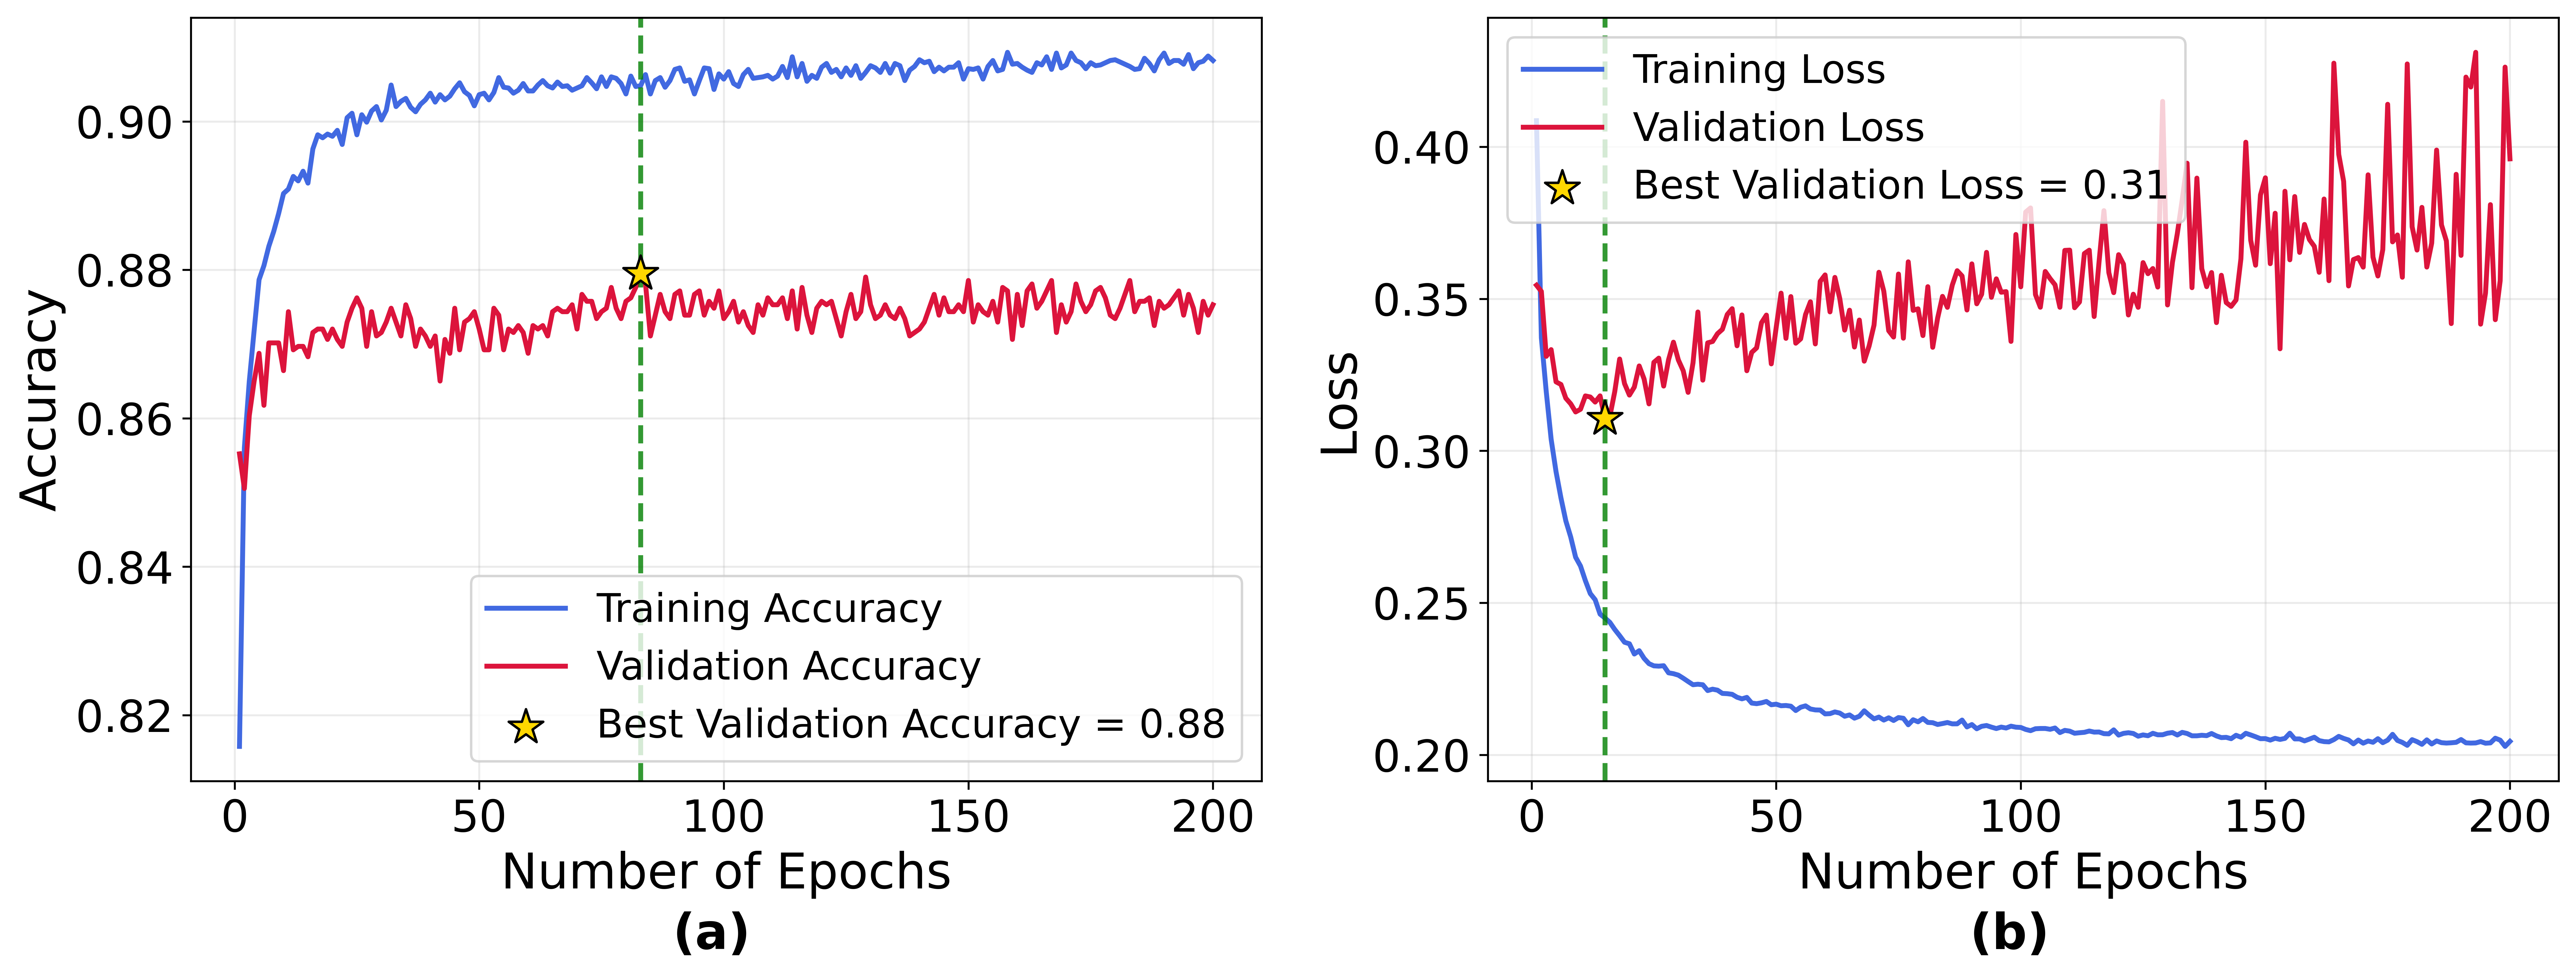

In [17]:
# ============================================================
# Font Settings
# ============================================================
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16
})

# ============================================================
# Identify Best Epochs
# ============================================================

if "epoch" not in df.columns:
    df["epoch"] = range(1, len(df) + 1)

best_acc_idx = df["val_accuracy"].idxmax()
best_acc_epoch = int(df.loc[best_acc_idx, "epoch"])
best_acc = float(df.loc[best_acc_idx, "val_accuracy"])

best_loss_idx = df["val_loss"].idxmin()
best_loss_epoch = int(df.loc[best_loss_idx, "epoch"])
best_loss = float(df.loc[best_loss_idx, "val_loss"])

# ============================================================
# Combined Learning Curves
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=600)

# ============================================================
# Accuracy Plot
# ============================================================
ax1.plot(df["epoch"], df["accuracy"], linewidth=2,
         color="royalblue", label="Training Accuracy")

ax1.plot(df["epoch"], df["val_accuracy"], linewidth=2,
         color="crimson", label="Validation Accuracy")

ax1.axvline(best_acc_epoch,
            linestyle="--",
            linewidth=2,
            color="green",
            alpha=0.8)

ax1.scatter(best_acc_epoch, best_acc,
            s=220, marker="*", color="gold", edgecolor="black",
            zorder=3,
            label=f"Best Validation Accuracy = {best_acc:.2f}")

ax1.set_xlabel("Number of Epochs")
ax1.set_ylabel("Accuracy")
ax1.grid(True, alpha=0.25)
ax1.legend(frameon=True)

# Accuracy plot ticks
for tick, label in zip(ax1.get_xticks(), ax1.get_xticklabels()):
    if int(tick) == best_acc_epoch:
        label.set_fontweight("bold")
        label.set_color("green")
        
# ============================================================
# Loss Plot
# ============================================================
ax2.plot(df["epoch"], df["loss"], linewidth=2,
         color="royalblue", label="Training Loss")

ax2.plot(df["epoch"], df["val_loss"], linewidth=2,
         color="crimson", label="Validation Loss")

ax2.axvline(best_loss_epoch,
            linestyle="--",
            linewidth=2,
            color="green",
            alpha=0.8)

ax2.scatter(best_loss_epoch, best_loss,
            s=220, marker="*", color="gold", edgecolor="black",
            zorder=3,
            label=f"Best Validation Loss = {best_loss:.2f}")

ax2.set_xlabel("Number of Epochs")
ax2.set_ylabel("Loss")
ax2.grid(True, alpha=0.25)
ax2.legend(frameon=True)

# Loss plot ticks
for tick, label in zip(ax2.get_xticks(), ax2.get_xticklabels()):
    if int(tick) == best_loss_epoch:
        label.set_fontweight("bold")
        label.set_color("green")
        
# ============================================================
# Panel Labels
# ============================================================
ax1.text(0.45, -0.22, "(a)", transform=ax1.transAxes,
         fontsize=20, fontweight="bold")

ax2.text(0.45, -0.22, "(b)", transform=ax2.transAxes,
         fontsize=20, fontweight="bold")

# ============================================================
# Final layout
# ============================================================
fig.tight_layout()

fig.savefig(os.path.join(OUTPUT_DIR, "learning_curves.png"),
            dpi=600, bbox_inches="tight")

fig.savefig(os.path.join(OUTPUT_DIR, "learning_curves.pdf"),
            bbox_inches="tight")

plt.show()

### Classification Report

313/313 [==============================] - 1s 2ms/step

Evaluation Results: Train
Accuracy  : 0.910802
Precision : 0.905261
Recall    : 0.917418
F1-score  : 0.911299
ROC AUC   : 0.975142
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.916481  0.904200  0.910299      5000
         1.0   0.905261  0.917418  0.911299      4989

    accuracy                       0.910802      9989
   macro avg   0.910871  0.910809  0.910799      9989
weighted avg   0.910877  0.910802  0.910799      9989



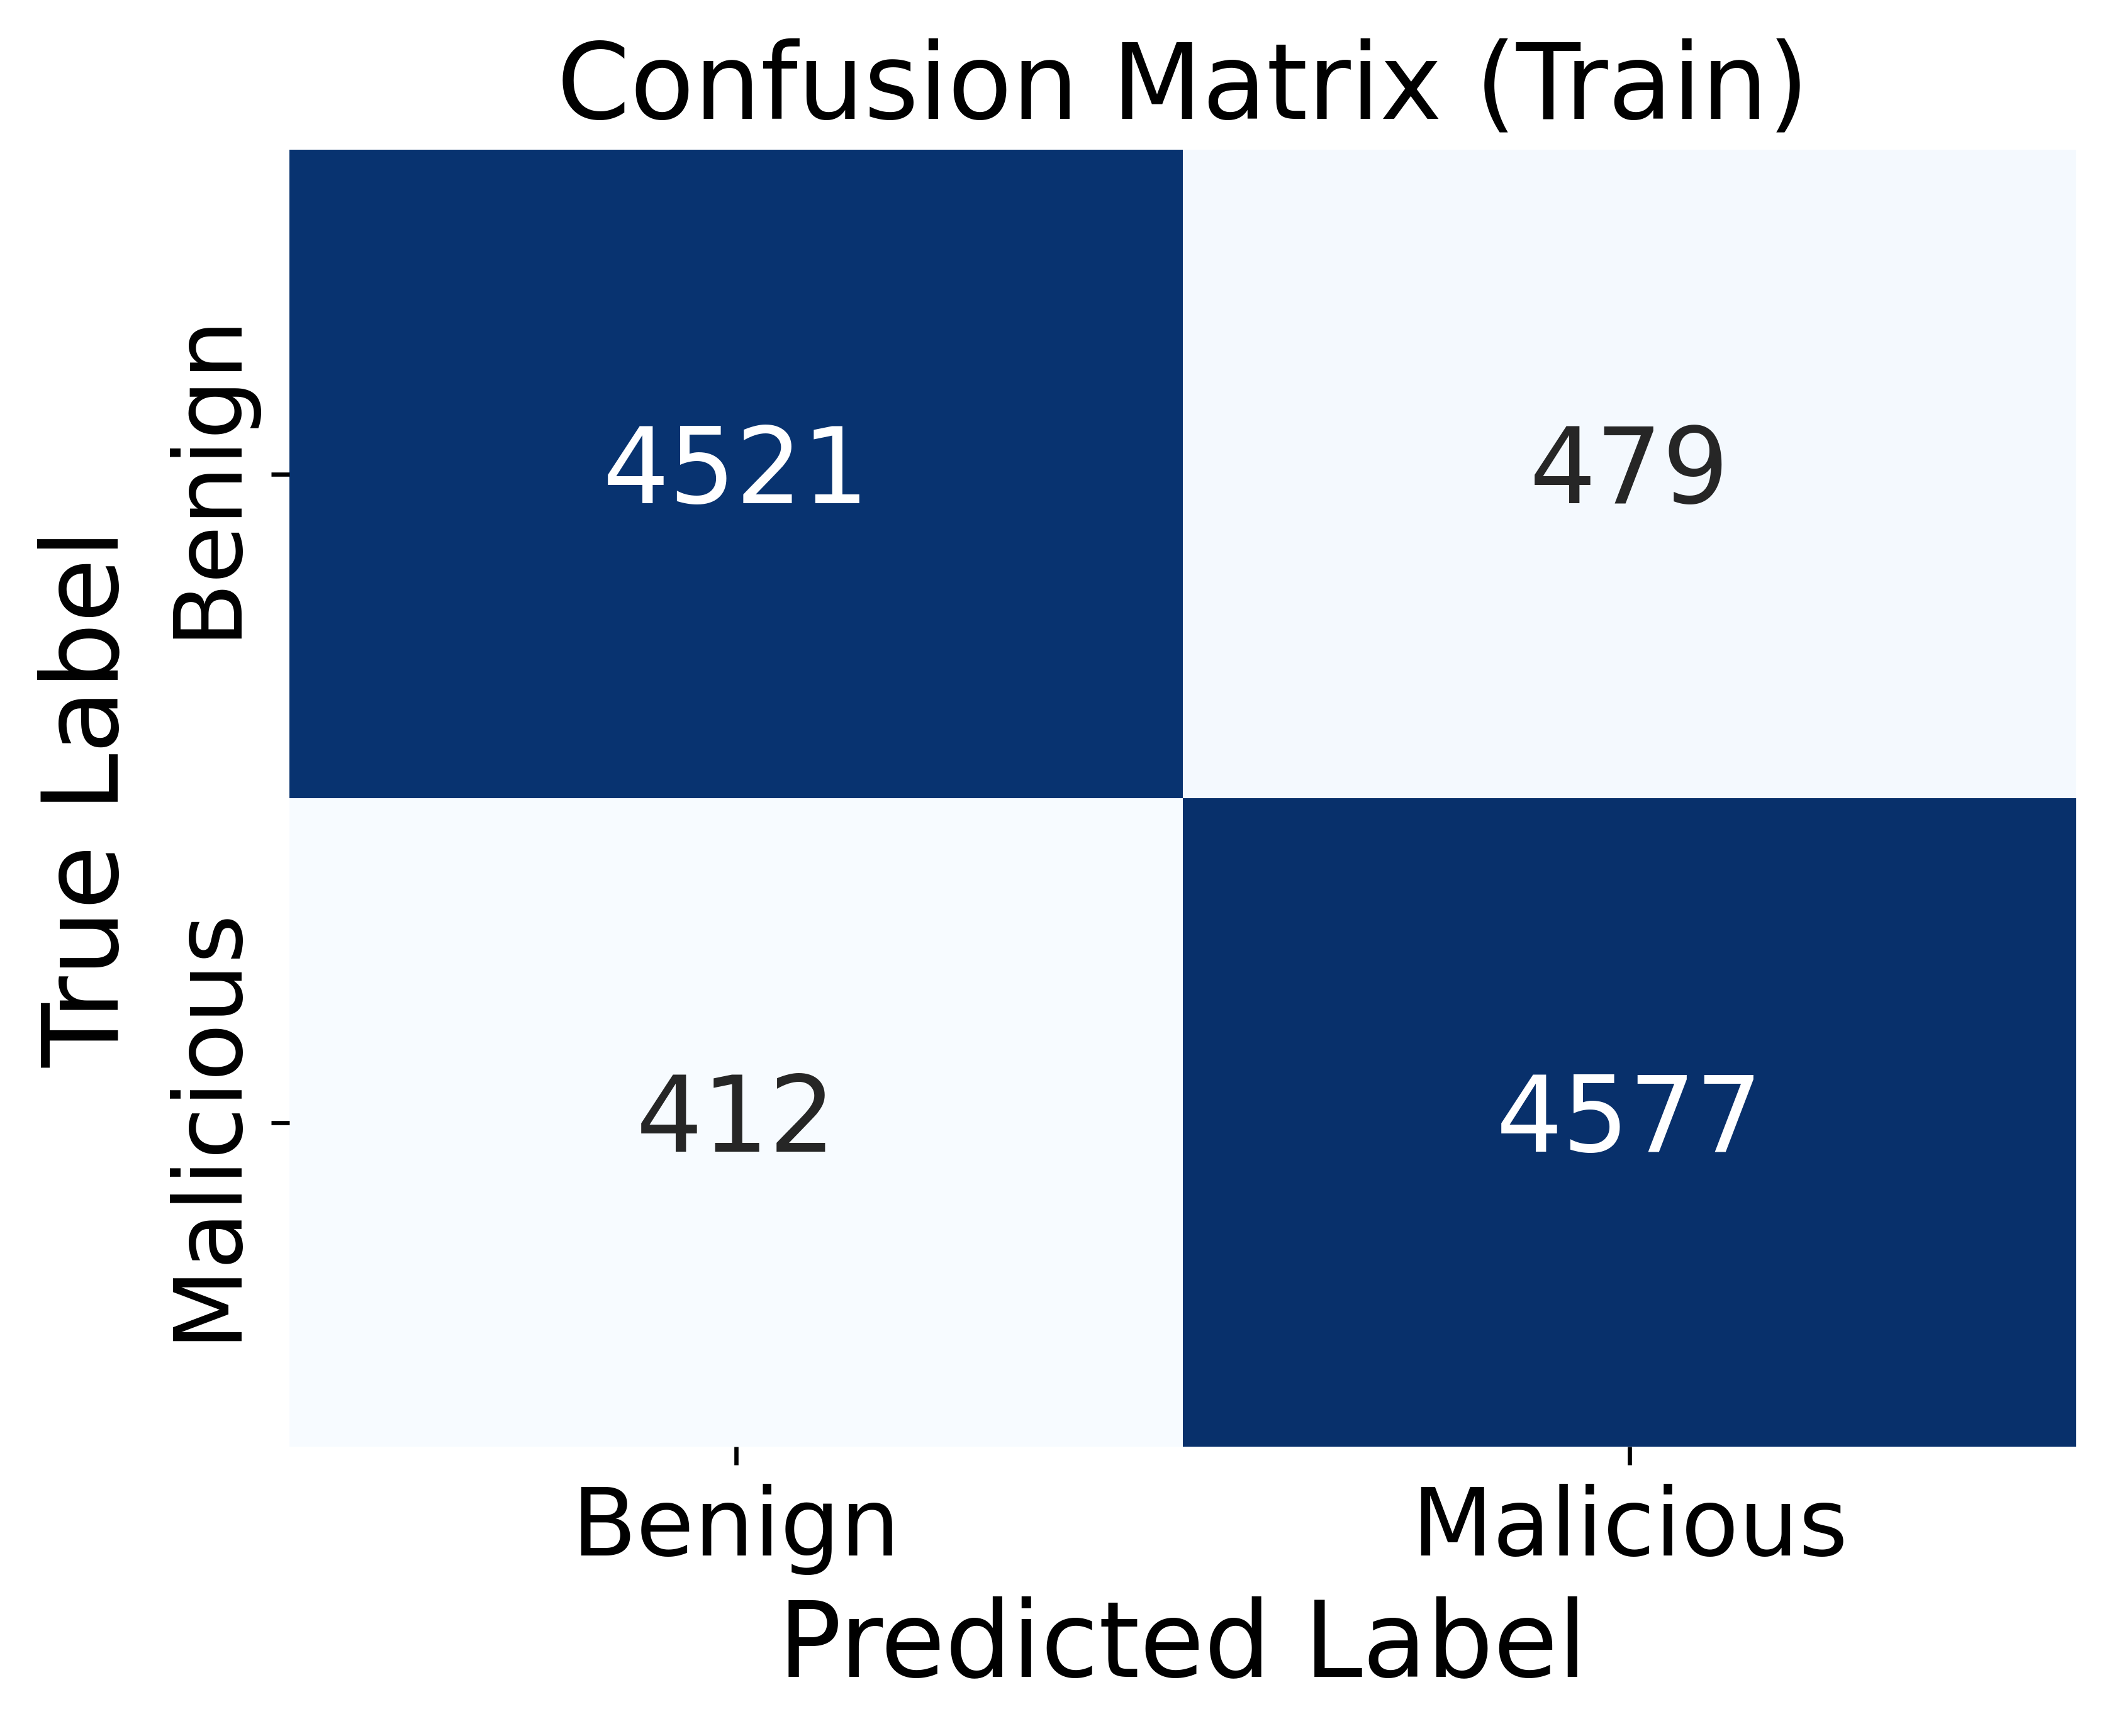

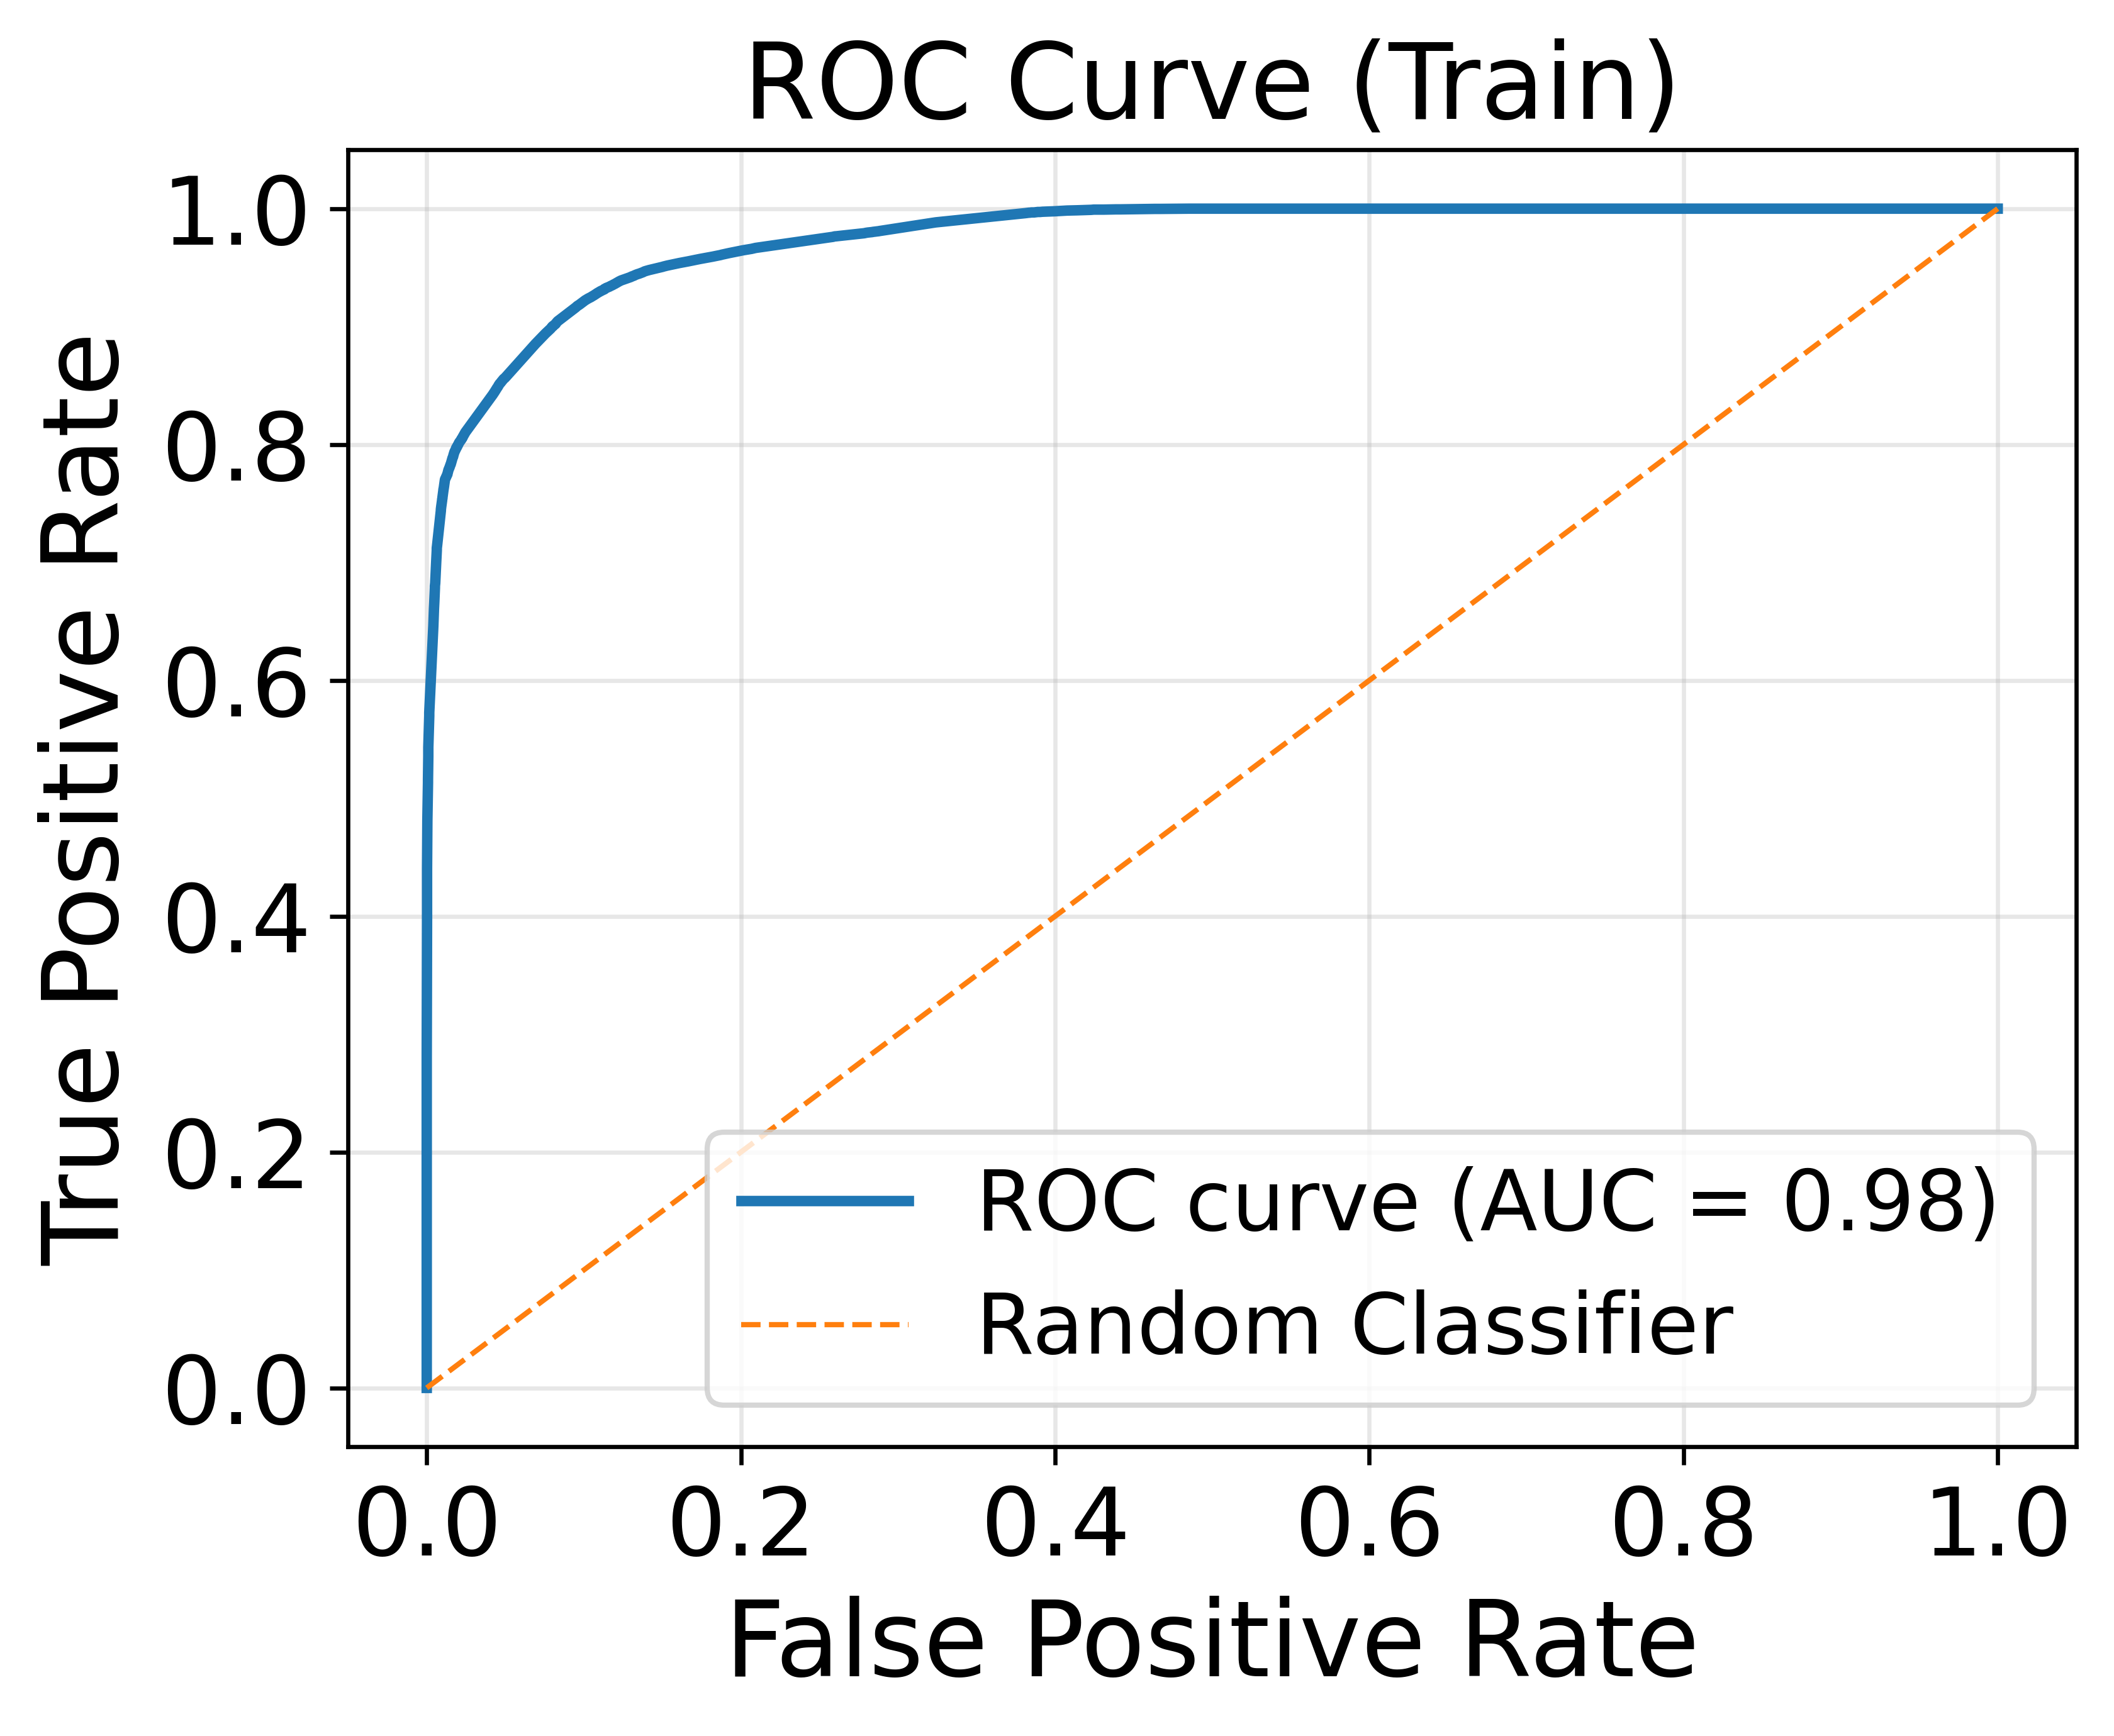

67/67 [==============================] - 0s 987us/step

Evaluation Results: Validation
Accuracy  : 0.875292
Precision : 0.883365
Recall    : 0.864359
F1-score  : 0.873759
ROC AUC   : 0.940293
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.867580  0.886194  0.876788      1072
         1.0   0.883365  0.864359  0.873759      1069

    accuracy                       0.875292      2141
   macro avg   0.875473  0.875277  0.875274      2141
weighted avg   0.875461  0.875292  0.875276      2141



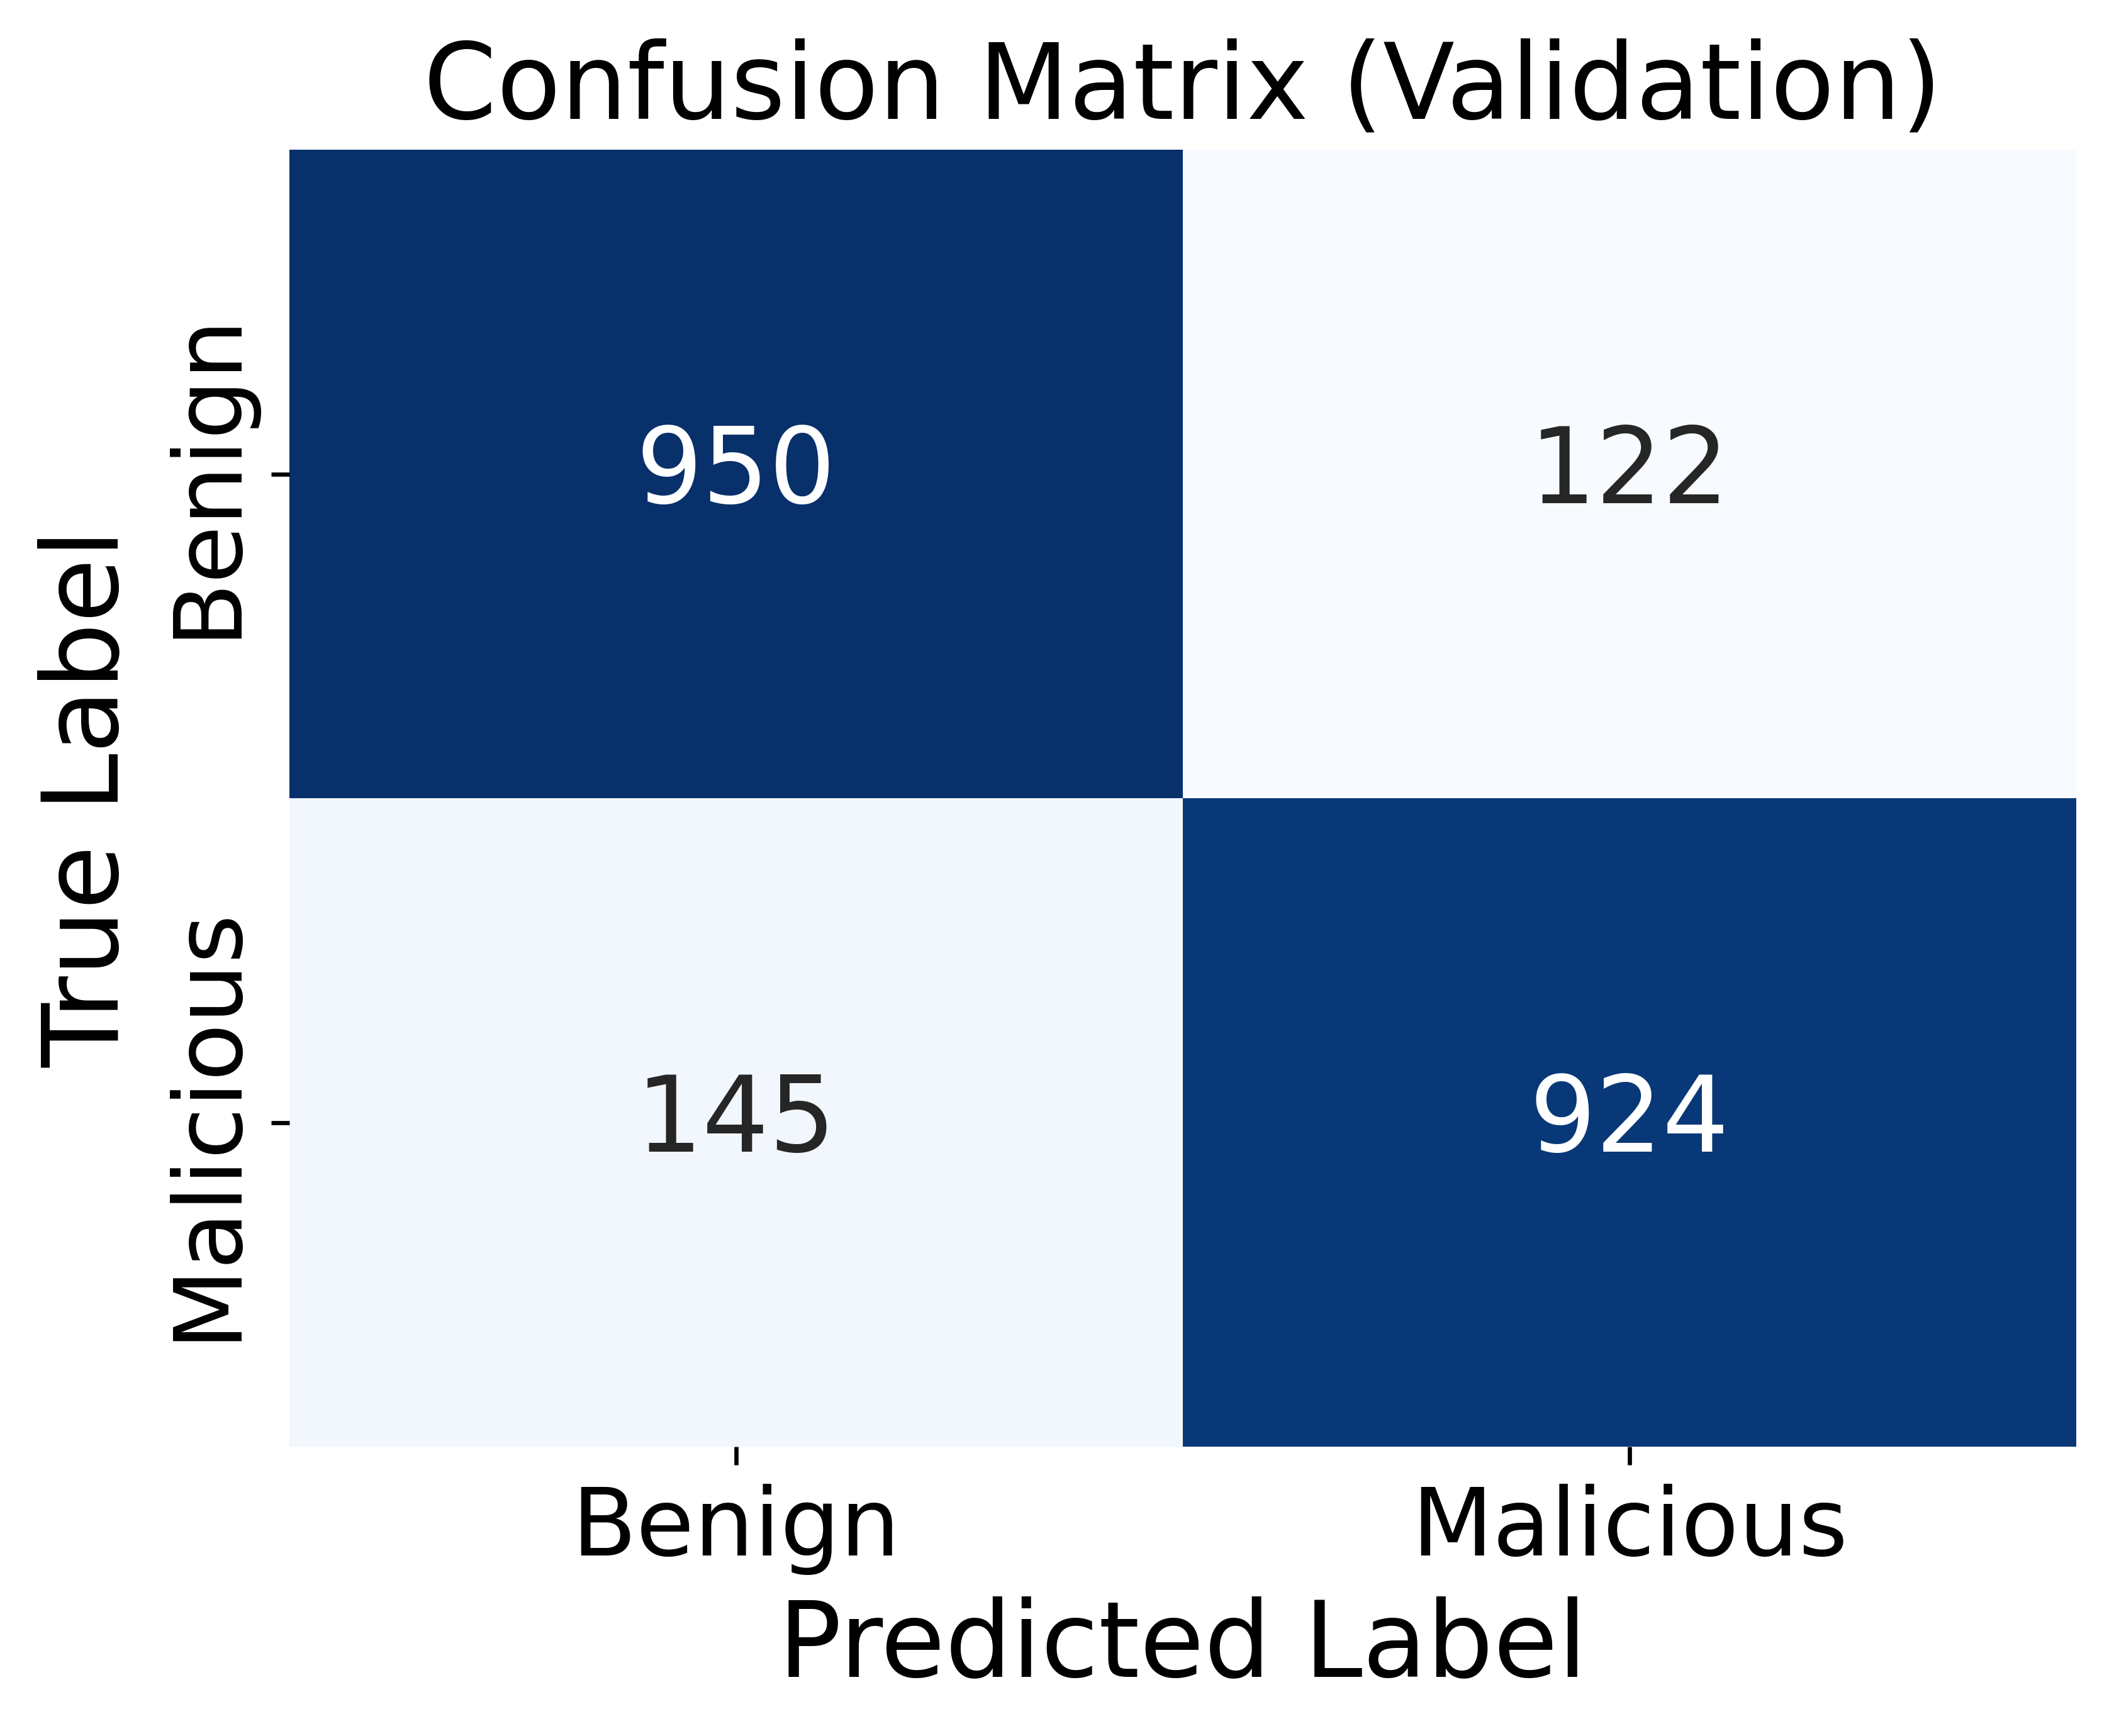

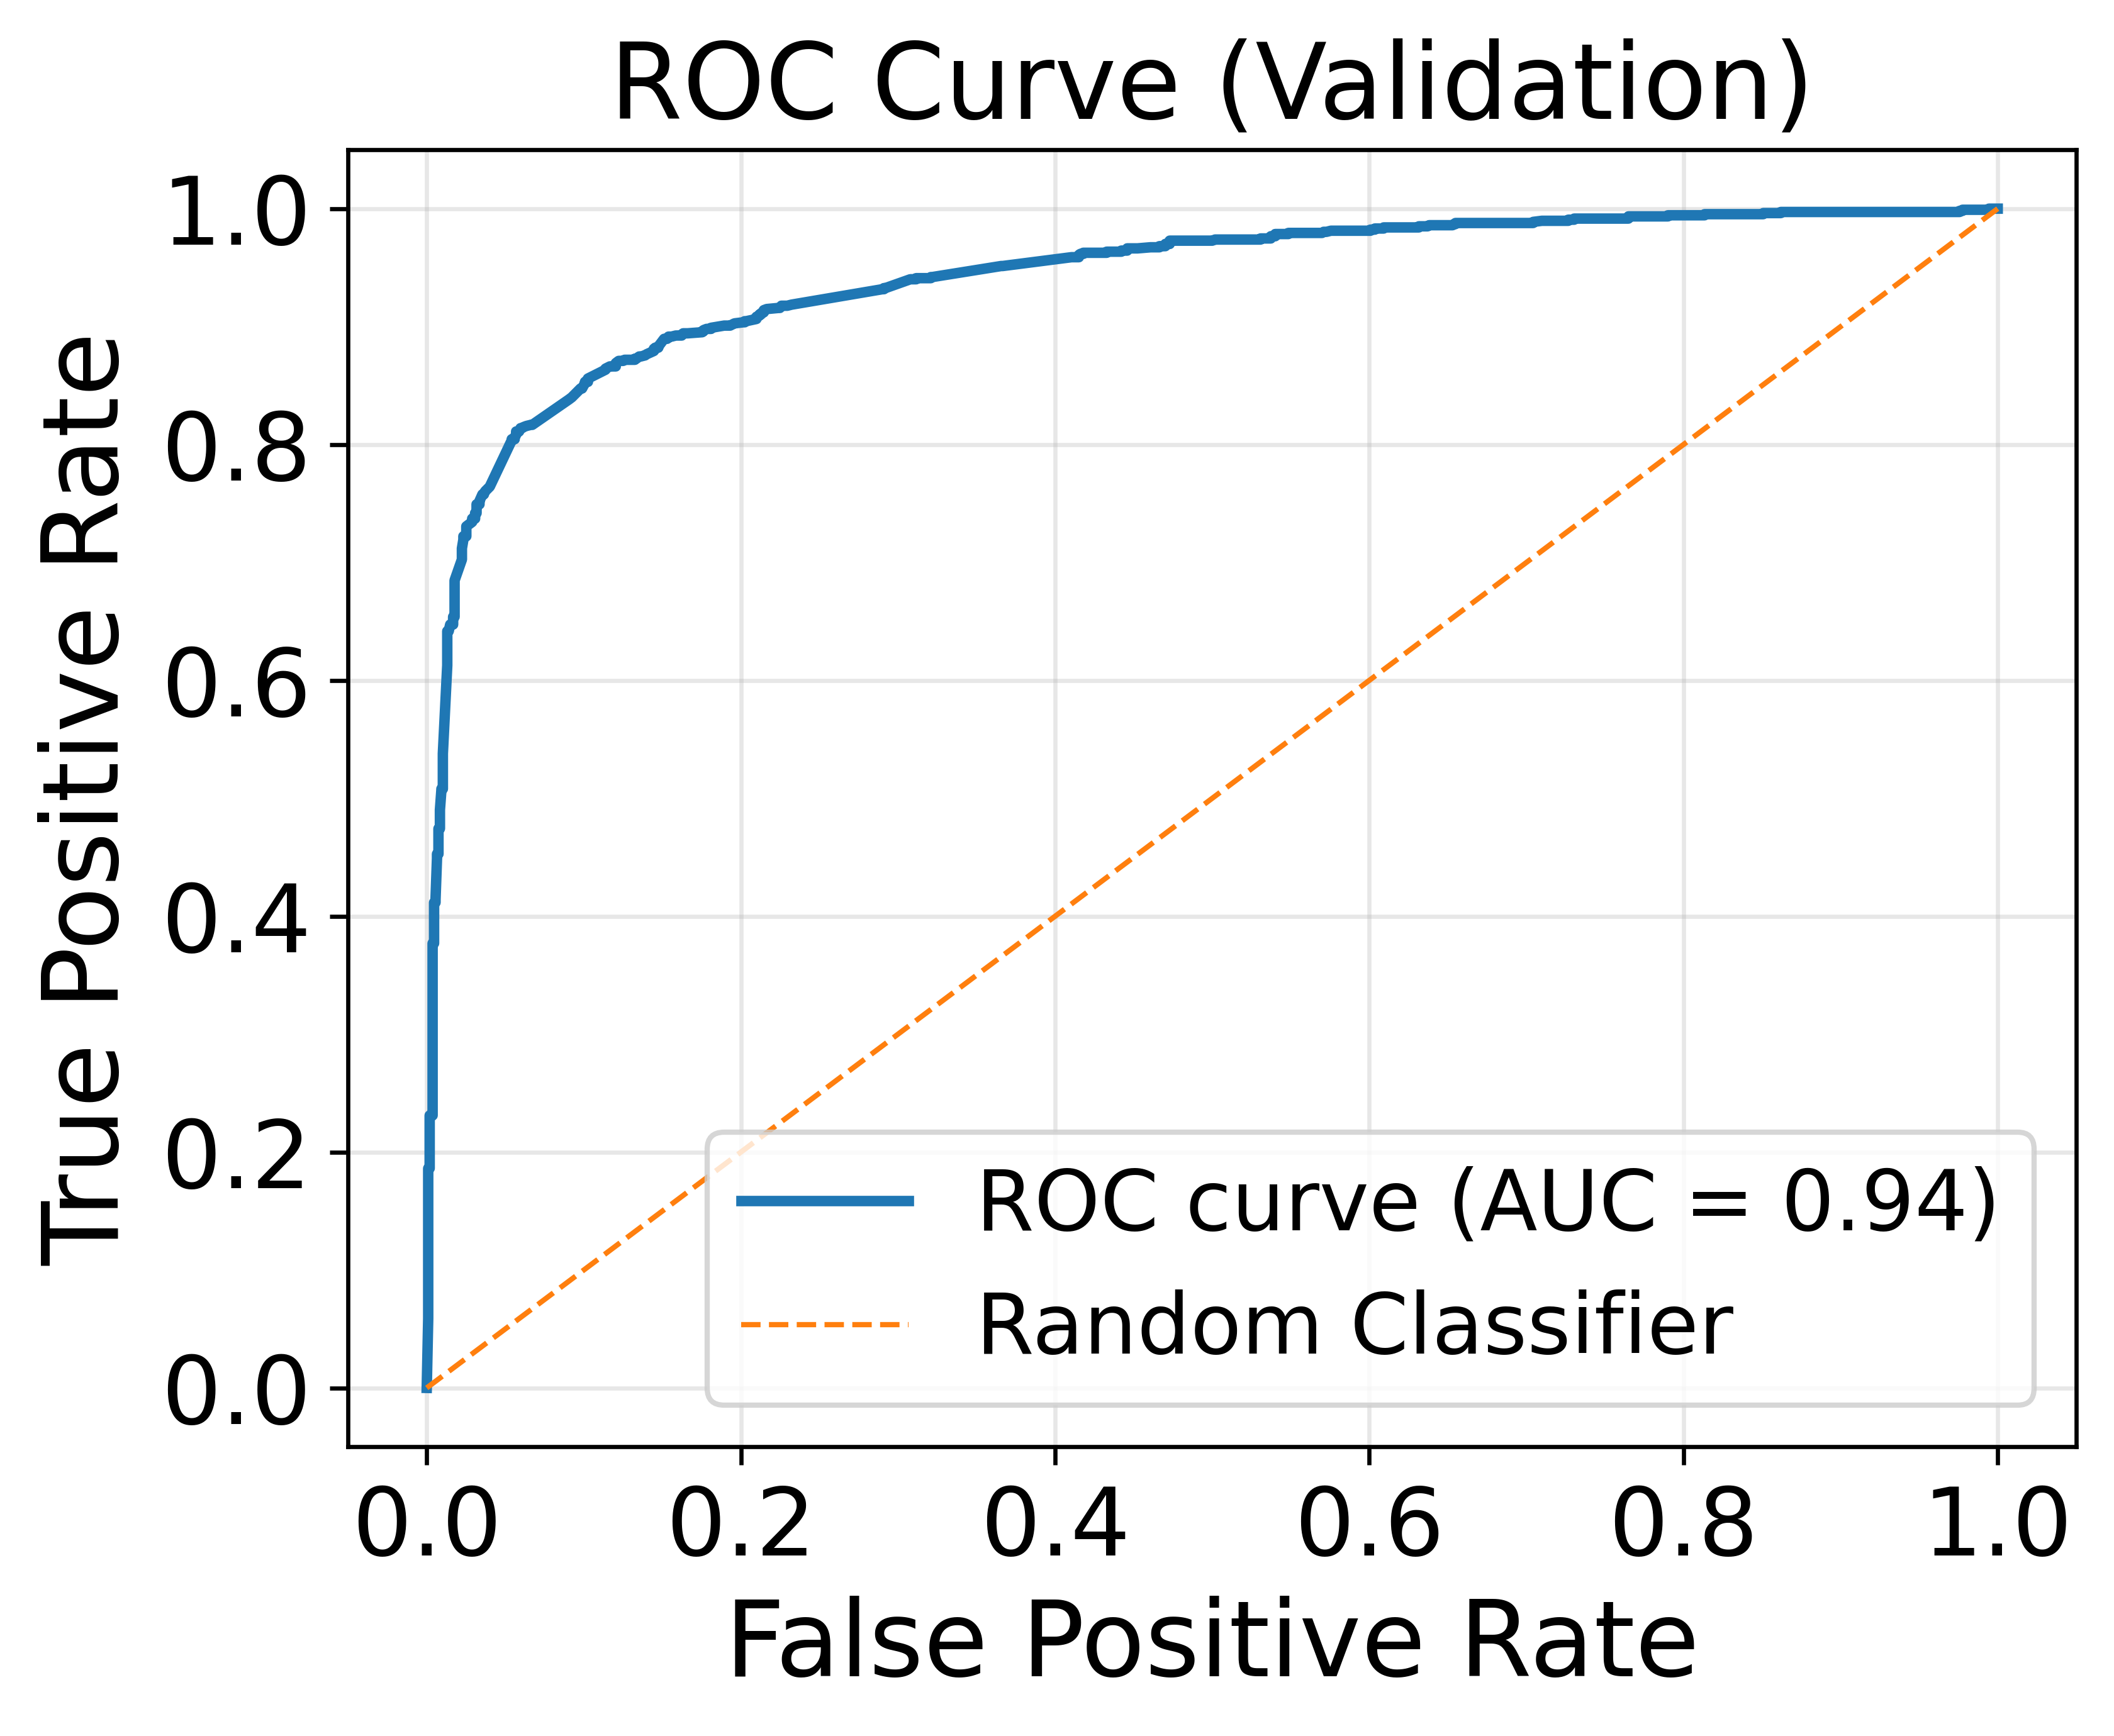

67/67 [==============================] - 0s 5ms/step

Evaluation Results: Test
Accuracy  : 0.882298
Precision : 0.877193
Recall    : 0.888681
F1-score  : 0.882900
ROC AUC   : 0.936430
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.887524  0.875933  0.881690      1072
         1.0   0.877193  0.888681  0.882900      1069

    accuracy                       0.882298      2141
   macro avg   0.882358  0.882307  0.882295      2141
weighted avg   0.882366  0.882298  0.882294      2141



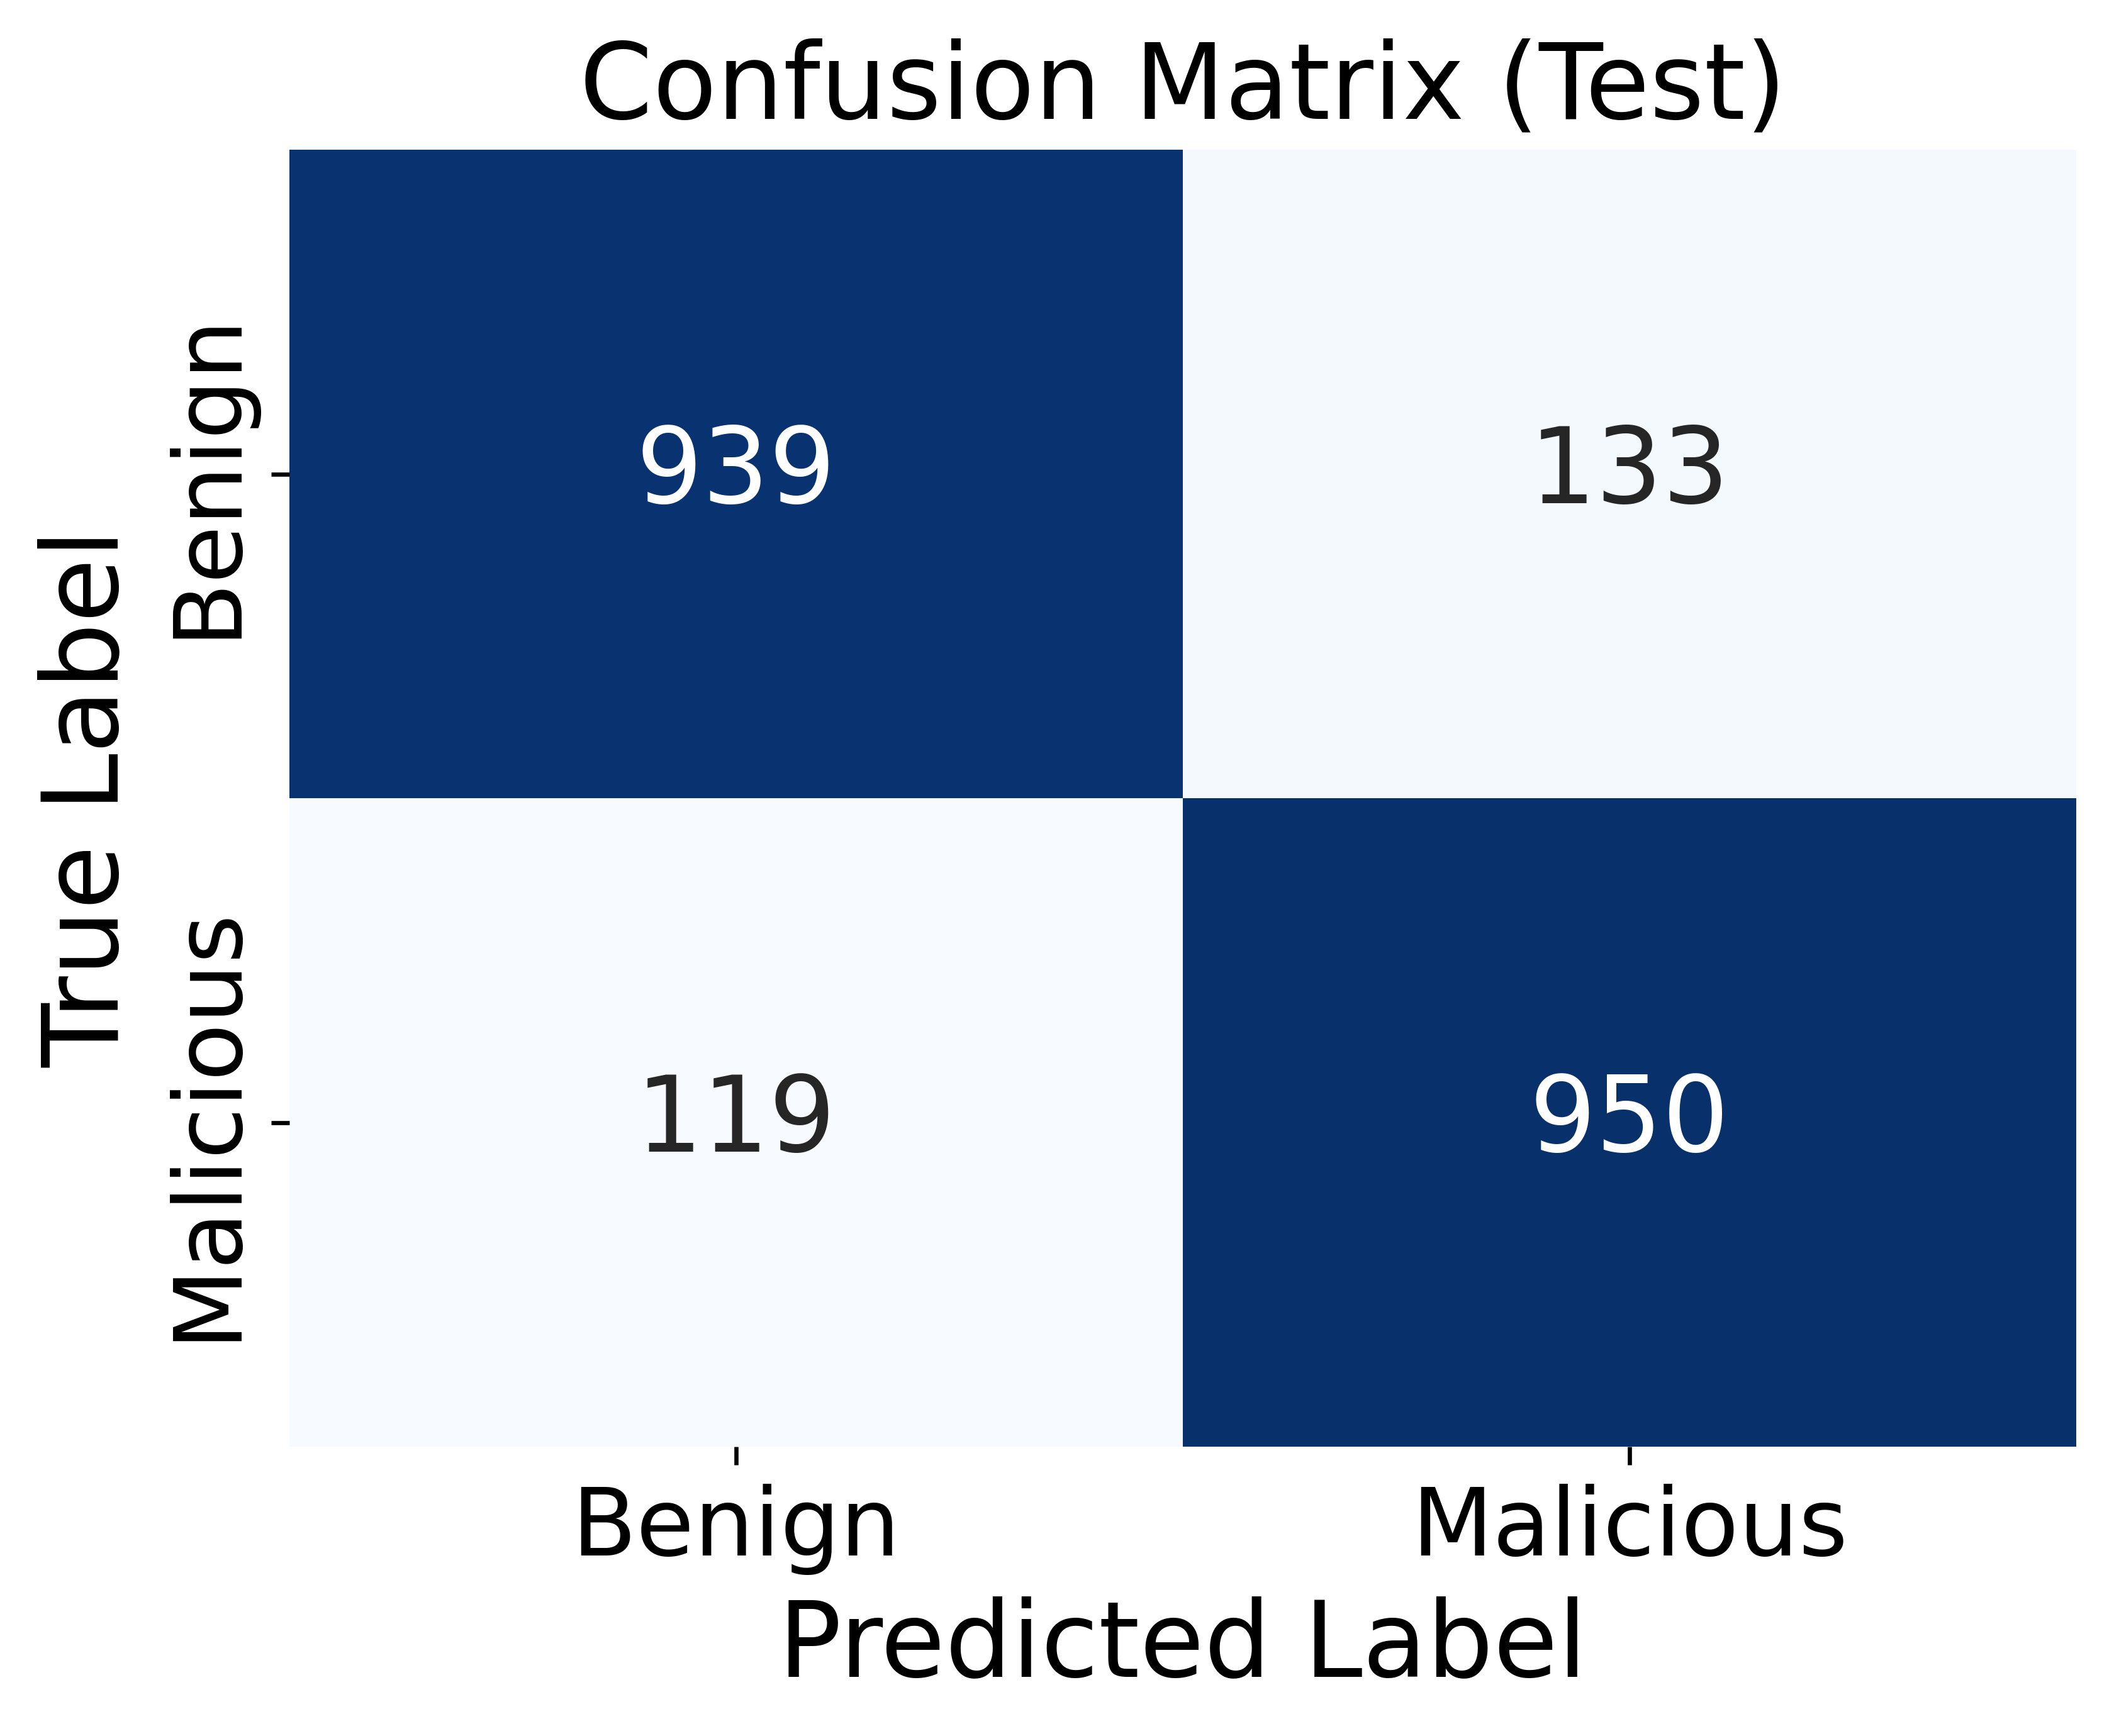

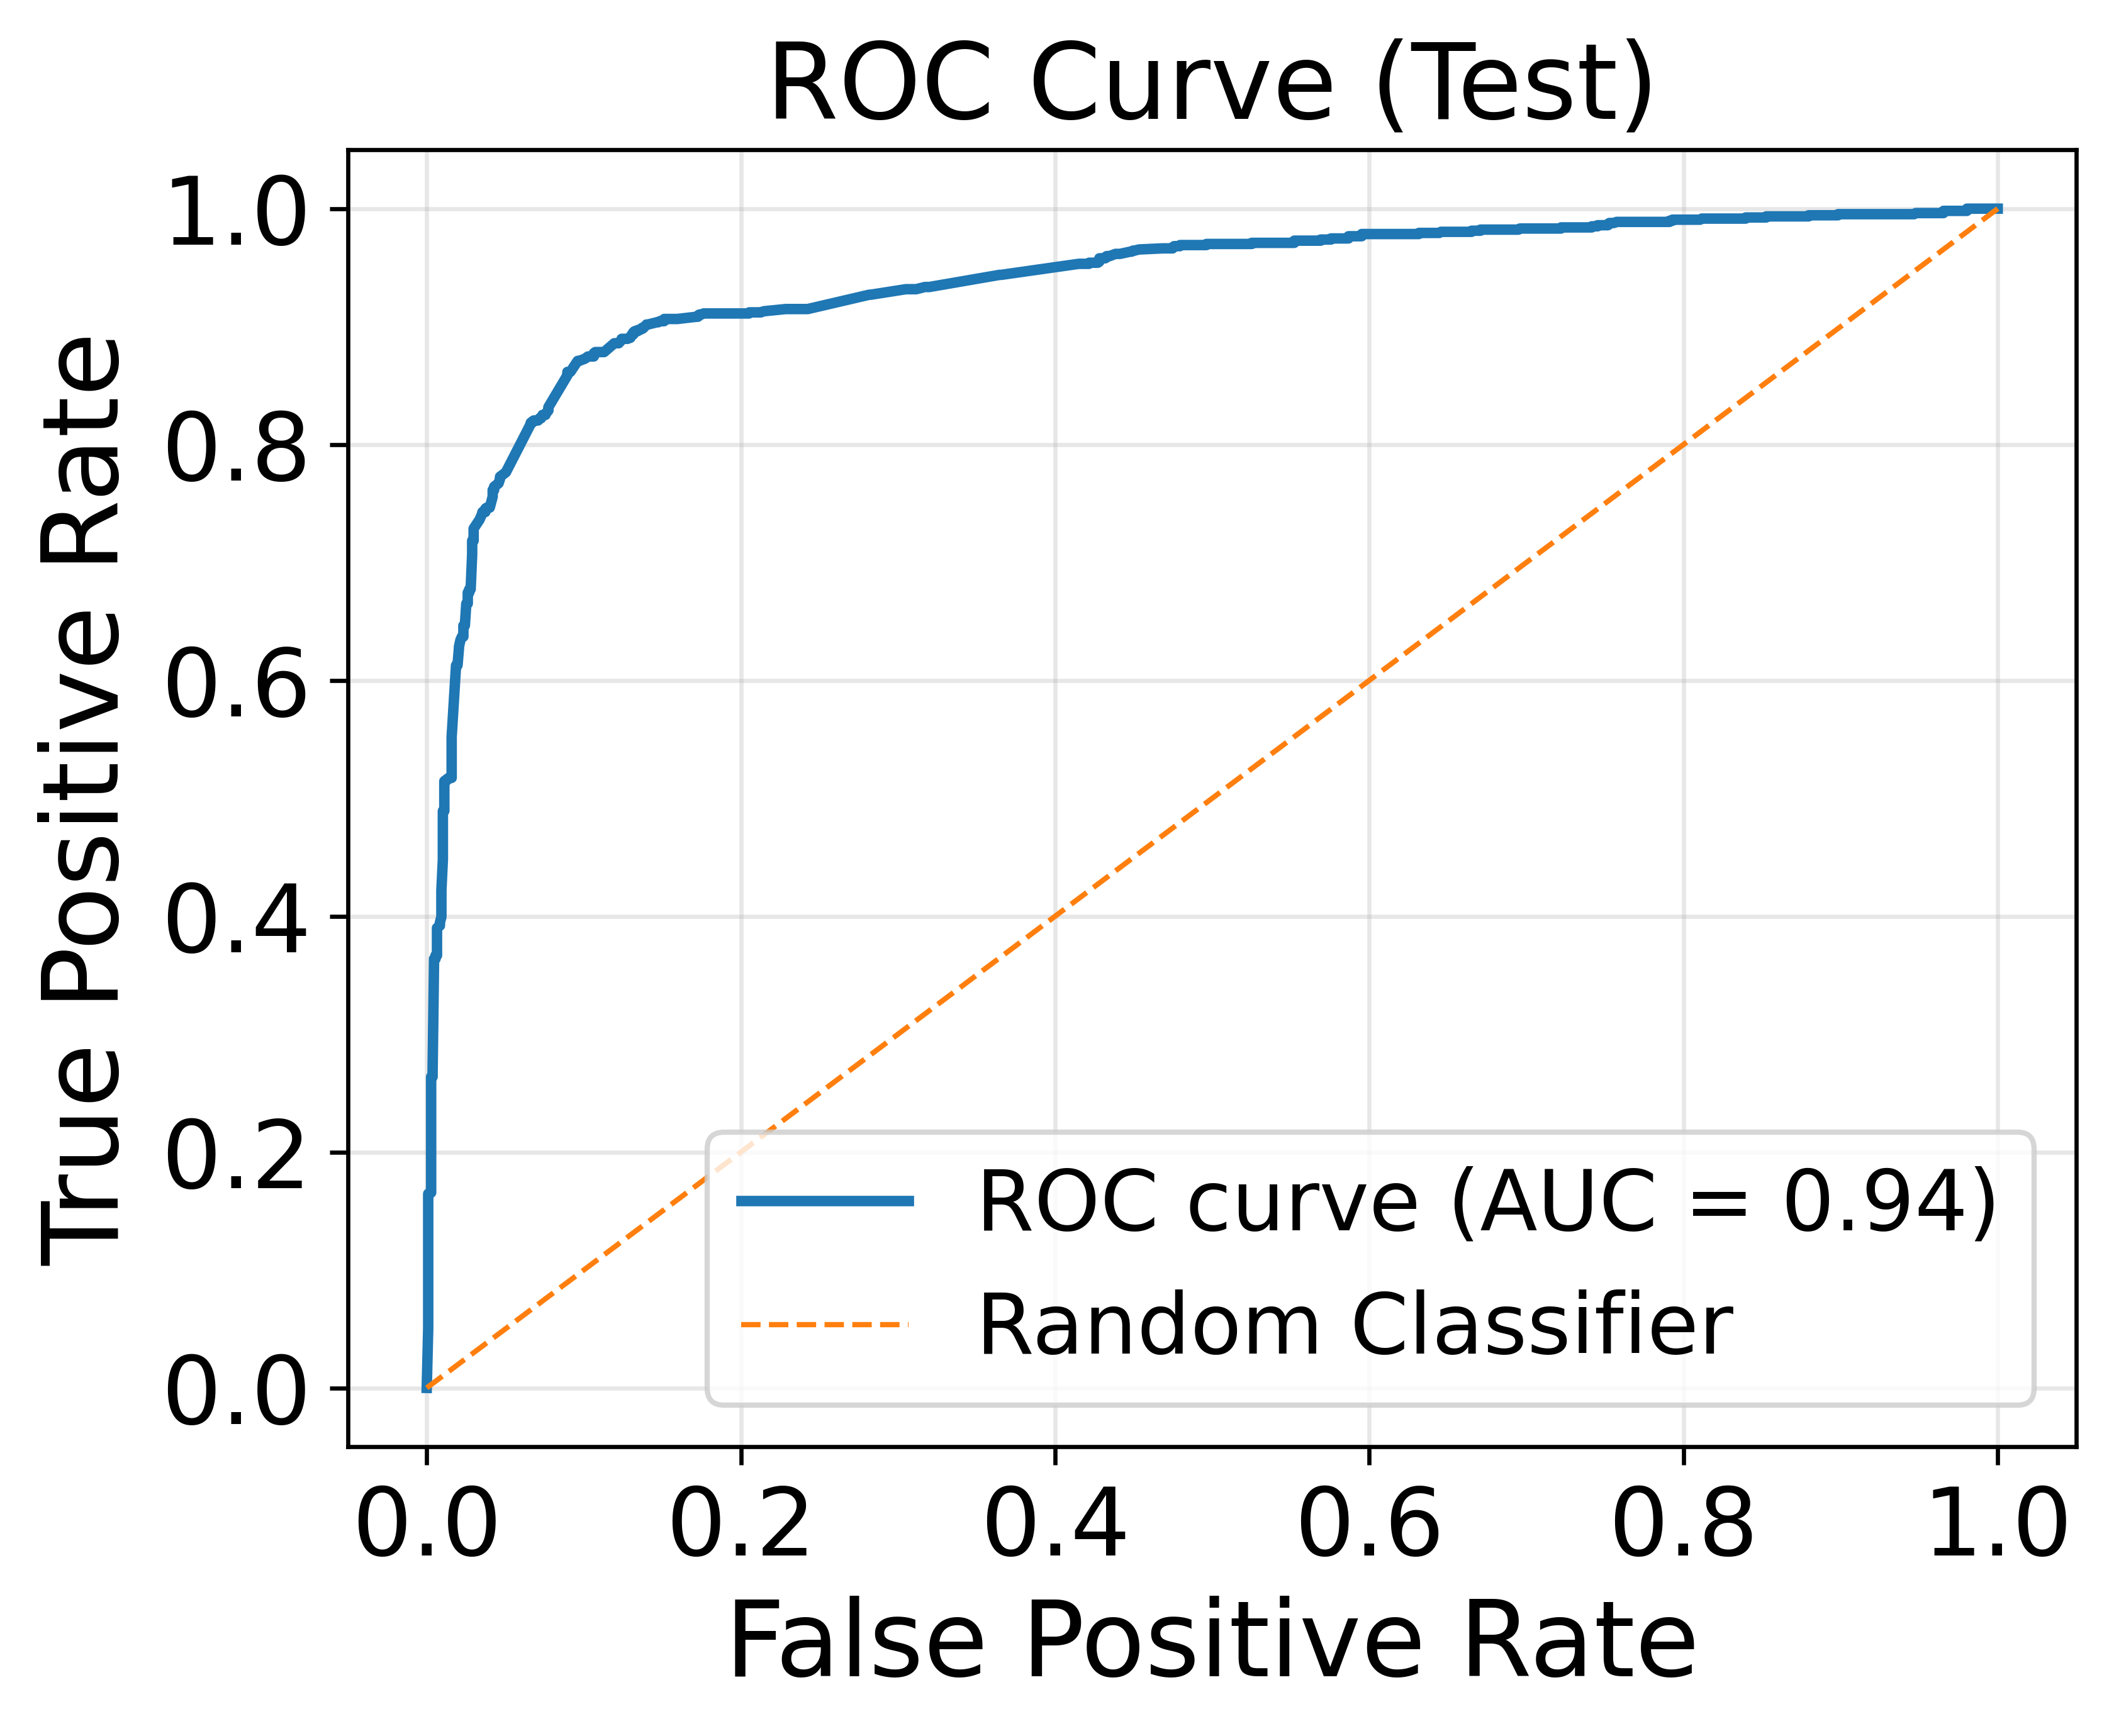

In [18]:
def evaluate_and_plot(model, X, y_true, dataset_name, output_dir=OUTPUT_DIR):
    """
    Evaluate the trained model on a given dataset and generate
    publication-quality confusion matrix and ROC curve figures.

    Parameters
    ----------
    model : keras.Model
        Trained classification model.
    encodings : dict or BatchEncoding
        Tokenized transformer inputs containing 'input_ids' and 'attention_mask'.
    y_true : array-like
        Ground-truth labels.
    dataset_name : str
        Name of the dataset split (e.g., 'Train', 'Validation', 'Test').
    output_dir : str, optional
        Directory where evaluation figures will be saved.

    Returns
    -------
    results : dict
        Dictionary containing predictions and evaluation metrics.
    """

    # --------------------------------------------------------
    # Generate predictions
    # --------------------------------------------------------
    y_prob = model.predict(X).ravel()
    y_pred = (y_prob > 0.5).astype("int32")

    # --------------------------------------------------------
    # Compute evaluation metrics
    # --------------------------------------------------------
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, digits=6)

    # --------------------------------------------------------
    # Print evaluation summary
    # --------------------------------------------------------
    print("\n" + "=" * 70)
    print(f"Evaluation Results: {dataset_name}")
    print("=" * 70)
    print(f"Accuracy  : {acc:.6f}")
    print(f"Precision : {prec:.6f}")
    print(f"Recall    : {rec:.6f}")
    print(f"F1-score  : {f1:.6f}")
    print(f"ROC AUC   : {roc_auc:.6f}")
    print("-" * 70)
    print("Classification Report:")
    print(report)

    # --------------------------------------------------------
    # Plot and save confusion matrix
    # --------------------------------------------------------
    plt.figure(figsize=(6, 5), dpi=600)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Benign", "Malicious"],
        yticklabels=["Benign", "Malicious"]
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix ({dataset_name})")
    plt.tight_layout()

    cm_png = os.path.join(output_dir, f"confusion_matrix_{dataset_name.lower()}.png")
    cm_pdf = os.path.join(output_dir, f"confusion_matrix_{dataset_name.lower()}.pdf")
    plt.savefig(cm_png, dpi=600, bbox_inches="tight")
    plt.savefig(cm_pdf, bbox_inches="tight")
    plt.show()

    # --------------------------------------------------------
    # Plot and save ROC curve
    # --------------------------------------------------------
    plt.figure(figsize=(6, 5), dpi=600)
    plt.plot(fpr, tpr, linewidth=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random Classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve ({dataset_name})")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    roc_png = os.path.join(output_dir, f"roc_curve_{dataset_name.lower()}.png")
    roc_pdf = os.path.join(output_dir, f"roc_curve_{dataset_name.lower()}.pdf")
    plt.savefig(roc_png, dpi=600, bbox_inches="tight")
    plt.savefig(roc_pdf, bbox_inches="tight")
    plt.show()

    # --------------------------------------------------------
    # Return results for further analysis/reporting
    # --------------------------------------------------------
    results = {
        "dataset": dataset_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "confusion_matrix": cm,
        "classification_report": report,
        "y_true": np.array(y_true),
        "y_pred": y_pred,
        "y_prob": y_prob,
        "confusion_matrix_png": cm_png,
        "confusion_matrix_pdf": cm_pdf,
        "roc_curve_png": roc_png,
        "roc_curve_pdf": roc_pdf
    }

    return results


# ============================================================
# Evaluate on Training, Validation, and Test Sets
# ============================================================

train_results = evaluate_and_plot(model, X_train_dense, y_train, "Train")
val_results   = evaluate_and_plot(model, X_val_dense, y_val, "Validation")
test_results  = evaluate_and_plot(model, X_test_dense, y_test, "Test")

### Save All Results

In [19]:
# ------------------------------------------------------------
# Create summary DataFrame
# ------------------------------------------------------------
summary_df = pd.DataFrame([
    {
        "Dataset": train_results["dataset"],
        "Accuracy": train_results["accuracy"],
        "Precision": train_results["precision"],
        "Recall": train_results["recall"],
        "F1-score": train_results["f1_score"],
        "ROC AUC": train_results["roc_auc"]
    },
    {
        "Dataset": val_results["dataset"],
        "Accuracy": val_results["accuracy"],
        "Precision": val_results["precision"],
        "Recall": val_results["recall"],
        "F1-score": val_results["f1_score"],
        "ROC AUC": val_results["roc_auc"]
    },
    {
        "Dataset": test_results["dataset"],
        "Accuracy": test_results["accuracy"],
        "Precision": test_results["precision"],
        "Recall": test_results["recall"],
        "F1-score": test_results["f1_score"],
        "ROC AUC": test_results["roc_auc"]
    }
])

# ------------------------------------------------------------
# Define save paths
# ------------------------------------------------------------
csv_path  = os.path.join(OUTPUT_DIR, "evaluation_summary.csv")
xlsx_path = os.path.join(OUTPUT_DIR, "evaluation_summary.xlsx")

# ------------------------------------------------------------
# Save files
# ------------------------------------------------------------
summary_df.to_csv(csv_path, index=False)
summary_df.to_excel(xlsx_path, index=False)

# ------------------------------------------------------------
# Confirmation
# ------------------------------------------------------------
print("=" * 60)
print("Evaluation summary saved successfully:")
print(f"CSV  : {csv_path}")
print(f"Excel: {xlsx_path}")
print("=" * 60)

# Display table
summary_df

Evaluation summary saved successfully:
CSV  : Evaluation_Outputs_Pattern_FLAML_Classical_LeNet/evaluation_summary.csv
Excel: Evaluation_Outputs_Pattern_FLAML_Classical_LeNet/evaluation_summary.xlsx


,Dataset,Accuracy,Precision,Recall,F1-score,ROC AUC
0,Train,0.910802,0.905261,0.917418,0.911299,0.975142
1,Validation,0.875292,0.883365,0.864359,0.873759,0.940293
2,Test,0.882298,0.877193,0.888681,0.882900,0.936430


### Clear Final Backend Session

In [20]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()